# Relative Valuation v8 + Excel Export

**v8 (2026-05-08)** — PBR/PSR/PER 모델 재정의:
- (A) BPS 시점 일치 — DuPont implied BVE = NI/ROE
- (B) PSR 독립 모델 — Gordon-on-Sales
- 결과: TP_PBR = TP_PER (수학적 일치) + TP_PSR (독립) → **2개 독립 valuation**

## v7 (2026-05-02) — 이전 변경

**v7** (2026-05-02) — Beta 계산 방식 전면 개편 (DCF v11.5 일관성 확보):
- **FDR OLS β**: `FinanceDataReader` 로 10년 monthly close → OLS 회귀 → Blume 조정
- **4단 Fallback Chain** (silent fallback 문제 해결):
  1. FDR OLS+Blume → `beta_source = "fdr_ols"`  ✓ 정상
  2. FMP `/beta` endpoint → `"fmp_beta"`  (FDR 데이터 부족)
  3. FMP `/key-metrics` → `"fmp_keymetrics"`
  4. SECTOR_BETA[sector] → `"sector_default"`  ⚠ 경고 표시
- **메타데이터 추가**: `beta_source`, `beta_r2`, `beta_n_obs` 를 DB·Excel 모두에 저장
- **Excel 시트 정정**: "Historical OLS regression" 라벨이 실제 source 를 정확히 반영하도록 수정

**v6** (2026-05-01) — Beta clipping (abs 제거) + g_cap 일관성 강화

---

# Relative Valuation (상대가치 평가) v7
## DuPont 2yr 예측 기반 PER / PBR / PSR 이론적 적정주가

### v1 → v7 핵심 변경 이력

| 버전 | 핵심 변경 |
|------|-----------|
| v1 | `g = clip(ROE×retention, 0, GDP=4%)` — 모든 기업에 동일 4% cap |
| v3 | ROE 구간별 g_cap 차별화 |
| v4 | NI → NOPAT(=OP×(1-t)) 교체 — FCFF 모델과 일관성 |
| v5 | Excel export (7-sheet) 추가 |
| v6 | β clipping (abs 제거) + g_cap 일관성 강화 (고성장 절대 8% cap) |
| **v7** | **β: FDR OLS+Blume (DCF v11.5 와 일관) + 4단 fallback + source tracking** |

### v7 베타 계산 방식 (DCF v11.5 와 동일)

```
β_raw = cov(rs, rm) / var(rm)         # OLS 회귀
β_blume = 0.67 × β_raw + 0.33 × 1.0   # Blume(1971) 조정
```

- **데이터**: FDR `DataReader(ticker, start, end)` — 10년 monthly close
- **벤치마크**: `US500` (FDR S&P 500), 실패 시 `^GSPC` 또는 `SPY` 자동 시도
- **최소 표본**: 60개월 (5년) 미만 시 fallback 으로 진행

### v7 β source 분류 (운영 시 모니터링 필수)

| Source | 의미 | 권장 처리 |
|--------|------|----------|
| `fdr_ols` | FDR OLS+Blume 정상 | ✓ 매수 후보 풀 포함 |
| `fmp_beta` | FDR 실패 → FMP 베타 사용 | ⚠ 검토 |
| `fmp_keymetrics` | FMP /beta 도 실패 | ⚠ 주의 |
| `sector_default` | 모든 API 실패 → 섹터 평균 | ⚠⚠ **매수 후보 풀에서 제외 권장** |

| Cell | 역할 |
|------|------|
| 1    | 경로 자동감지 (노트북/데스크탑) |
| 2    | Import & 상수 (FDR 추가) |
| 3    | DB 연결 & 테이블 (beta_source 컬럼 추가 ALTER 필요) |
| 4    | RelativeValModel 클래스 (v7) |
| 4.5  | Excel Export (7-sheet, source 표시 정정) |
| 5    | 배치 실행 |
| 6    | 결과 조회 & 시각화 |
| 7    | g × Re 민감도 분석 |

## Cell 1 · 경로 자동감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\\ubc14\ud0d1 \ud654\uba74\\investment\\investment_strategy",
]

# 실제 경로 (raw string으로 직접 지정)
_CANDIDATE_ROOTS = [
    "C:/Users/Hoyoung_Park/PyCharmMiscProject/stock_forecast",
    "C:/Users/82108/OneDrive/바탕 화면/investment/investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] 자동 감지: {root}")
            return root
    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "DATA")):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f"[PATH] 후보 경로: {candidate}")
            return candidate
    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다. _CANDIDATE_ROOTS 를 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")


[PATH] 자동 감지: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · Import & 설정 상수

In [2]:
import gc, math, time, traceback, warnings
import requests
from datetime import datetime, timedelta
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

# ── v7: FinanceDataReader (베타 OLS 회귀용) ─────────────────────
import FinanceDataReader as fdr

from DATA.config import get_db_info, get_engine
from DATA.us_target_ticker_list_screened_20260411 import ticker_list as US_TICKER_LIST

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ===== 설정 상수 =====
FMP_API_KEY  = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"
FMP_BASE     = "https://financialmodelingprep.com/api/v3"
FMP_LIMIT    = 40
FMP_SLEEP    = 0.35

TABLE_SALES  = "us_revenue_forecast_data"
TABLE_RE     = "us_rim_spread_data"
TABLE_RESULT = "us_relative_valuation"  # v7: 동일 테이블, beta_source/r2/n_obs 컬럼 추가 필요
DEFAULT_PORT = 3307

FORECAST_HORIZON = 8
MIN_HISTORY      = 12
OLS_MIN_R2       = 0.20
OLS_MIN_SAMPLES  = 12
WINSORIZE_LIMITS = (0.05, 0.95)
GDP_GROWTH       = 0.04

# ── ROE 구간별 g cap 상수 (v6 유지) ────────────────────────────────
ROE_MID_THRESHOLD  = 0.15
ROE_HIGH_THRESHOLD = 0.30
G_CAP_MID_FIXED    = 0.08
G_CAP_RE_RATIO     = 0.75

W_INDIVIDUAL = 0.60
W_SECTOR     = 0.40

# ── Damodaran Implied ERP & Risk-Free Rate (수동 갱신) ──────────────
ERP_SOURCE_DATE = "2026-05-01"
RF           = 0.045
ERP          = 0.055
RE_FLOOR     = 0.07
RE_CAP       = 0.18

# ── Beta clipping 상수 (v6 유지) ────────────────────────────────
BETA_MIN    = 0.3
BETA_MAX    = 3.0
BETA_DELTA  = 0.20

# ── v7: FDR OLS β 회귀 상수 ────────────────────────────────────
# DCF v11.5 와 일관성 유지 (10년 monthly + Blume 조정)
BETA_YEARS         = 10            # FDR 가격 데이터 fetch 기간 (년)
BETA_MIN_OBS       = 60            # OLS 최소 표본 (월) — 미달 시 fallback
BETA_BENCHMARKS    = ["US500", "^GSPC", "SPY"]  # FDR 벤치마크 — 순서대로 시도
BLUME_W_RAW        = 0.67          # Blume(1971) 학술 표준
BLUME_W_MARKET     = 0.33

# 제외 업종
EXCLUDE_SECTORS = {
    "Real Estate", "Energy", "Communication Services",
    "Financials", "Insurance", "REIT", "ETF", "Foreign", "Utilities",
}

SECTOR_MAP = {
    "Real Estate": "Real Estate", "Energy": "Energy",
    "Communication Services": "Communication Services",
    "Financials": "Financials", "Financial Services": "Financials",
    "Insurance": "Insurance", "Utilities": "Utilities",
    "Consumer Defensive": "Consumer Defensive",
    "Consumer Cyclical": "Consumer Cyclical",
    "Healthcare": "Healthcare", "Technology": "Technology",
    "Industrials": "Industrials", "Basic Materials": "Basic Materials",
    "Consumer Staples": "Consumer Defensive",
}

INDUSTRY_OVERRIDE = {
    "REIT": "REIT", "Real Estate Investment": "REIT",
    "ETF": "ETF", "Exchange Traded Fund": "ETF",
}

SECTOR_BETA = {
    "Technology": 1.25, "Healthcare": 0.85,
    "Consumer Cyclical": 1.05, "Consumer Defensive": 0.65,
    "Industrials": 1.00, "Basic Materials": 0.95,
    "Communication Services": 0.90, "Energy": 1.10,
    "Financials": 0.80, "Real Estate": 0.75, "REIT": 0.70,
    "Insurance": 0.85, "Utilities": 0.45,
    "ETF": 1.00, "Foreign": 1.10, "Unknown": 1.00,
}

TICKER_START = 0
TICKER_END   = 1000
SKIP_DONE    = False

CHECKPOINT_DIR = "_relval_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DONE_PATH = os.path.join(CHECKPOINT_DIR, "done_tickers.txt")
FAIL_PATH = os.path.join(CHECKPOINT_DIR, "failed_tickers.txt")

db_info = get_db_info()
engine  = get_engine(db_info)

print(f"[OK] Import 완료 v7 | 대상 티커: {len(US_TICKER_LIST):,}개")
print(f"[설정] FORECAST_HORIZON={FORECAST_HORIZON}Q  GDP_GROWTH={GDP_GROWTH}")
print(f"[설정 v7] β: FDR OLS {BETA_YEARS}Y monthly + Blume({BLUME_W_RAW}/{BLUME_W_MARKET}) "
      f"| min_obs={BETA_MIN_OBS} | benchmarks={BETA_BENCHMARKS}")
print(f"[설정] β fallback chain: fdr_ols → fmp_beta → fmp_keymetrics → sector_default")
print(f"[설정] β clip=[{BETA_MIN}, {BETA_MAX}]  앙상블: individual×{W_INDIVIDUAL} + sector×{W_SECTOR}")
print(f"[설정] ERP={ERP:.1%} (source: Damodaran, updated: {ERP_SOURCE_DATE})  RF={RF:.1%}")
print(f"[설정] g_cap: 저성장(ROE<{ROE_MID_THRESHOLD:.0%})=GDP({GDP_GROWTH:.0%}) | "
      f"중·고성장(ROE>={ROE_MID_THRESHOLD:.0%})=min({G_CAP_MID_FIXED:.0%}, Re×{G_CAP_RE_RATIO})")
print(f"[설정] 제외 업종: {EXCLUDE_SECTORS}")
print(f"\n[필수] DB 스키마 업데이트 (한 번만):")
print(f"  ALTER TABLE `{TABLE_RESULT}`")
print(f"    ADD COLUMN beta_source VARCHAR(20) NULL,")
print(f"    ADD COLUMN beta_r2 DECIMAL(6,4) NULL,")
print(f"    ADD COLUMN beta_n_obs INT NULL;")


[OK] Import 완료 v7 | 대상 티커: 1,026개
[설정] FORECAST_HORIZON=8Q  GDP_GROWTH=0.04
[설정 v7] β: FDR OLS 10Y monthly + Blume(0.67/0.33) | min_obs=60 | benchmarks=['US500', '^GSPC', 'SPY']
[설정] β fallback chain: fdr_ols → fmp_beta → fmp_keymetrics → sector_default
[설정] β clip=[0.3, 3.0]  앙상블: individual×0.6 + sector×0.4
[설정] ERP=5.5% (source: Damodaran, updated: 2026-05-01)  RF=4.5%
[설정] g_cap: 저성장(ROE<15%)=GDP(4%) | 중·고성장(ROE>=15%)=min(8%, Re×0.75)
[설정] 제외 업종: {'Utilities', 'Energy', 'Communication Services', 'Financials', 'ETF', 'REIT', 'Insurance', 'Foreign', 'Real Estate'}

[필수] DB 스키마 업데이트 (한 번만):
  ALTER TABLE `us_relative_valuation`
    ADD COLUMN beta_source VARCHAR(20) NULL,
    ADD COLUMN beta_r2 DECIMAL(6,4) NULL,
    ADD COLUMN beta_n_obs INT NULL;


## Cell 3 · DB 연결 & 테이블 초기화

In [3]:
def get_conn():
    return pymysql.connect(
        host=db_info["host"], port=int(db_info.get("port", DEFAULT_PORT)),
        user=db_info["user"], password=db_info["password"],
        db=db_info.get("database", "investar"),
        charset="utf8mb4", autocommit=False,
        cursorclass=pymysql.cursors.DictCursor,
    )

CREATE_SQL = """
CREATE TABLE IF NOT EXISTS `us_relative_valuation` (
  `id`               BIGINT      NOT NULL AUTO_INCREMENT,
  `date`             DATE        NOT NULL COMMENT '예측 실행일',
  `ticker`           VARCHAR(20) NOT NULL,
  `sector`           VARCHAR(50)          COMMENT '업종',
  `is_excluded`      TINYINT(1)  DEFAULT 0 COMMENT '제외 업종 여부 1=제외',
  `sales_y1`         DOUBLE,  `sales_y2` DOUBLE,
  `npm_y1`           DOUBLE,  `npm_y2`   DOUBLE,
  `at_y1`            DOUBLE,  `at_y2`    DOUBLE,
  `fl_y1`            DOUBLE,  `fl_y2`    DOUBLE,
  `roe_y1`           DOUBLE,  `roe_y2`   DOUBLE,
  `ni_y2`            DOUBLE,  `bve_y2`   DOUBLE,
  `eps_y2`           DOUBLE,  `bps_y2`   DOUBLE,  `sps_y2` DOUBLE,
  `payout_ratio`     DOUBLE,  `g_est`    DOUBLE,
  `beta_raw`         DOUBLE,  `beta_blume` DOUBLE,
  `beta_sector`      DOUBLE,  `beta_ensemble` DOUBLE,
  `re_low`           DOUBLE,  `re_mid`   DOUBLE,  `re_high` DOUBLE,
  `pbr_theory`       DOUBLE,  `psr_theory` DOUBLE, `per_theory` DOUBLE,
  `tp_pbr`           DOUBLE,  `tp_psr`   DOUBLE,  `tp_per`  DOUBLE, `tp_avg` DOUBLE,
  `tp_pbr_low`       DOUBLE,  `tp_pbr_high` DOUBLE,
  `tp_psr_low`       DOUBLE,  `tp_psr_high` DOUBLE,
  `current_price`    DOUBLE,
  `upside_pbr`       DOUBLE,  `upside_psr` DOUBLE,
  `upside_per`       DOUBLE,  `upside_avg` DOUBLE,
  `actual_pbr`       DOUBLE,  `actual_psr` DOUBLE, `actual_per` DOUBLE,
  `created_at`       DATETIME DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`),
  INDEX idx_ticker   (`ticker`),
  INDEX idx_date     (`date`),
  INDEX idx_sector   (`sector`),
  INDEX idx_excluded (`is_excluded`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""
conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"테이블 준비: {TABLE_RESULT}")
finally:
    conn.close()

try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"연결 성공 host={db_info.get('host')}:{db_info.get('port')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")

# ── done_tickers.txt 관리 유틸 ──────────────────────────────────────
# 새 날짜로 전체 재실행하려면 아래 코드를 실행하세요 (주석 해제)
# import glob
# for f in glob.glob(os.path.join(CHECKPOINT_DIR, "*.txt")):
#     os.remove(f)
#     print(f"[삭제] {f}")
# print("[완료] checkpoint 초기화 — 다음 배치 실행 시 전체 재계산됩니다")


[21:01:09][DB] 테이블 준비: us_relative_valuation
[21:01:09][DB] 연결 성공 host=192.168.0.230:3307


## Cell 4 · RelativeValModel 클래스

In [4]:
# RelativeValModel — 상대가치 평가 모델 v7
# DuPont 2yr 예측 -> PBR/PSR/PER 이론적 멀티플 -> 적정주가 -> 괴리율
#
# v6→v7 변경 요약:
#   v6: β clipping (abs 제거) + g_cap 일관성 강화
#   v7: (a) FDR OLS+Blume β 추가 (DCF v11.5 와 일관),
#       (b) 4단 fallback chain + beta_source 추적,
#       (c) Excel 시트 source 표시 정정 (Cell 10 별도 수정)

class RelativeValModel:
    """
    상대가치 3종 적정주가 평가 (v7).

    공식:
      PBR_theory = (ROE - g) / (Re - g)      [Gordon Growth]
      PSR_theory = PBR × NPM / ROE
      PER_theory = PBR / ROE

    v7 β 계산 chain (silent fallback 문제 해결):
      1차: FDR DataReader 10Y monthly OLS + Blume → source="fdr_ols"
      2차: FMP /beta endpoint                       → source="fmp_beta"
      3차: FMP /key-metrics                          → source="fmp_keymetrics"
      4차: SECTOR_BETA[sector]                       → source="sector_default" ⚠

    v7 g_cap 정책 (v6 유지):
      저성장 ROE < 15%: g_cap = GDP (4%)
      중·고성장 ROE >= 15%: g_cap = min(8%, Re×0.75)
    """

    def __init__(self, ticker: str, engine, fmp_api_key: str = FMP_API_KEY,
                 verbose: bool = False):
        self.ticker   = ticker.upper()
        self.engine   = engine
        self.api_key  = fmp_api_key
        self.verbose  = verbose
        self._sales_actual   = None
        self._sales_forecast = None
        self._inc  = None
        self._bs   = None
        self._cf   = None
        self._sector      = "Unknown"
        self._is_excluded = False
        self.valuation    = None
        self._monthly_prices = None   # v7: FDR 캐시

    @staticmethod
    def _winsorize(s):
        lo, hi = s.quantile(WINSORIZE_LIMITS[0]), s.quantile(WINSORIZE_LIMITS[1])
        return s.clip(lo, hi)

    def _fmp_get(self, endpoint, period="quarter", limit=FMP_LIMIT):
        url = f"{FMP_BASE}/{endpoint}/{self.ticker}"
        for attempt in range(3):
            try:
                r = requests.get(url, params={"period":period,"limit":limit,
                                              "apikey":self.api_key}, timeout=12)
                if r.status_code == 429:
                    time.sleep(1.5 + attempt); continue
                r.raise_for_status()
                data = r.json()
                if isinstance(data, dict) and "Error Message" in data:
                    return pd.DataFrame()
                return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame()
            except Exception as e:
                if attempt == 2:
                    if self.verbose: log(self.ticker, f"FMP {endpoint} fail: {e}")
                    return pd.DataFrame()
                time.sleep(FMP_SLEEP + attempt * 0.5)
        return pd.DataFrame()

    def _parse_date_col(self, df):
        df = df.copy()
        df["report_date"] = pd.to_datetime(
            df.get("acceptedDate", df.get("fillingDate", pd.NaT)), errors="coerce")
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        def _qend(row):
            if pd.notna(row.get("report_date")):
                return (row["report_date"] - pd.Timedelta(days=45)).to_period("Q").to_timestamp("Q")
            return row["date"].to_period("Q").to_timestamp("Q")
        df["date"] = df.apply(_qend, axis=1)
        return df.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)

    def _n(self, val):
        if val is None: return None
        try:
            f = float(val)
            return None if (np.isnan(f) or np.isinf(f)) else f
        except (TypeError, ValueError):
            return val

    # --- 1. Sales 로드 ---
    def load_sales(self):
        conn_local = get_conn()
        try:
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT date, value FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='actual' ORDER BY date",
                    (self.ticker,))
                actual_rows = cur.fetchall()
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT MAX(forecast_date) AS max_fd FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='forecast'",
                    (self.ticker,))
                row = cur.fetchone()
                max_fd = row["max_fd"] if row else None
            fc_rows = []
            if max_fd:
                with conn_local.cursor() as cur:
                    cur.execute(
                        f"SELECT date, model, value FROM `{TABLE_SALES}` "
                        f"WHERE ticker=%s AND item='sale' AND data_type='forecast' "
                        f"AND forecast_date=%s ORDER BY model, date",
                        (self.ticker, max_fd))
                    fc_rows = cur.fetchall()
        finally:
            conn_local.close()

        if not actual_rows:
            raise ValueError(f"[{self.ticker}] Sales 실적 없음")

        act_df = pd.DataFrame(actual_rows)
        act_df["date"]  = pd.to_datetime(act_df["date"])
        act_df["value"] = pd.to_numeric(act_df["value"], errors="coerce")
        actual = (act_df.sort_values("date").drop_duplicates("date", keep="last")
                        .set_index("date")["value"])

        if not fc_rows:
            raise ValueError(f"[{self.ticker}] Sales forecast 없음")

        fc_df = pd.DataFrame(fc_rows)
        fc_df["date"]  = pd.to_datetime(fc_df["date"])
        fc_df["value"] = pd.to_numeric(fc_df["value"], errors="coerce")

        priority = ["Ensemble","SARIMA","ETS","Theta"]
        available = fc_df["model"].unique().tolist()
        ordered   = [m for m in priority if m in available] + \
                    [m for m in available if m not in priority]

        forecast = pd.Series(dtype=float)
        for mn in ordered:
            fc = (fc_df[fc_df["model"]==mn].sort_values("date")
                     .drop_duplicates("date",keep="last")
                     .set_index("date")["value"].dropna())
            if len(fc) >= FORECAST_HORIZON:
                forecast = fc.iloc[:FORECAST_HORIZON]; break
            elif len(fc) > 0 and forecast.empty:
                forecast = fc

        if forecast.empty:
            raise ValueError(f"[{self.ticker}] forecast empty")

        if len(forecast) < FORECAST_HORIZON:
            extra_idx = pd.date_range(
                start=forecast.index[-1] + pd.offsets.QuarterEnd(1),
                periods=FORECAST_HORIZON - len(forecast), freq="QE")
            forecast = pd.concat([forecast,
                pd.Series([float(forecast.iloc[-1])]*len(extra_idx), index=extra_idx)])

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:FORECAST_HORIZON]
        if self.verbose:
            log(self.ticker, f"Sales actual={len(actual)}Q forecast={len(self._sales_forecast)}Q")
        return self

    # --- 2. 재무제표 ---
    def load_financials(self):
        time.sleep(FMP_SLEEP)
        inc = self._fmp_get("income-statement")
        time.sleep(FMP_SLEEP)
        bs  = self._fmp_get("balance-sheet-statement")
        time.sleep(FMP_SLEEP)
        cf  = self._fmp_get("cash-flow-statement")
        if inc.empty or bs.empty:
            raise ValueError(f"[{self.ticker}] IS/BS load failed")
        self._inc = self._parse_date_col(inc)
        self._bs  = self._parse_date_col(bs)
        self._cf  = self._parse_date_col(cf) if not cf.empty else None
        if self.verbose:
            cf_q = len(self._cf) if self._cf is not None else 0
            log(self.ticker, f"IS={len(self._inc)}Q BS={len(self._bs)}Q CF={cf_q}Q")
        return self

    # --- 3. 업종 분류 ---
    def load_sector(self):
        sector = "Unknown"; industry = ""
        try:
            r = requests.get(f"{FMP_BASE}/profile/{self.ticker}",
                             params={"apikey":self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                p = data[0]
                sector   = p.get("sector","Unknown") or "Unknown"
                industry = p.get("industry","") or ""
                country  = p.get("country","US") or "US"
                if country not in ("US",""):
                    sector = "Foreign"
                if p.get("isEtf", False) or "ETF" in industry.upper():
                    sector = "ETF"
        except Exception:
            pass
        for kw, override in INDUSTRY_OVERRIDE.items():
            if kw.upper() in industry.upper():
                sector = override; break
        sector = SECTOR_MAP.get(sector, sector)
        self._sector      = sector
        self._is_excluded = sector in EXCLUDE_SECTORS
        if self.verbose:
            excl = " [EXCLUDED]" if self._is_excluded else ""
            log(self.ticker, f"sector={sector}{excl} industry={industry[:30]}")
        return self

    # ════════════════════════════════════════════════════════════════
    #  v7 신규: FDR 가격 데이터 fetch + OLS Blume β
    # ════════════════════════════════════════════════════════════════
    def _fetch_monthly_prices_fdr(self, years: int = BETA_YEARS) -> Optional[pd.DataFrame]:
        """FDR 로 ticker + benchmark monthly close fetch.

        BETA_BENCHMARKS 순서대로 시도하며, 첫 번째 성공한 벤치마크 사용.
        실패 시 None 반환 (estimate_beta_re 가 fallback 처리).
        """
        end_dt   = datetime.today()
        start_dt = end_dt - timedelta(days=years * 365 + 30)

        # 1) ticker 가격
        try:
            df_t = fdr.DataReader(self.ticker, start_dt, end_dt)
            if df_t is None or df_t.empty or "Close" not in df_t.columns:
                if self.verbose: log(self.ticker, f"[v7] FDR ticker fetch empty")
                return None
            ticker_monthly = df_t["Close"].astype(float).resample("ME").last().dropna()
        except Exception as e:
            if self.verbose: log(self.ticker, f"[v7] FDR ticker fail: {type(e).__name__}: {str(e)[:80]}")
            return None

        if len(ticker_monthly) < BETA_MIN_OBS:
            if self.verbose:
                log(self.ticker, f"[v7] FDR ticker monthly={len(ticker_monthly)} < {BETA_MIN_OBS}")
            return None

        # 2) 벤치마크 (순서대로 시도)
        bench_monthly = None
        bench_used    = None
        for bench_code in BETA_BENCHMARKS:
            try:
                df_m = fdr.DataReader(bench_code, start_dt, end_dt)
                if df_m is None or df_m.empty or "Close" not in df_m.columns:
                    continue
                series = df_m["Close"].astype(float).resample("ME").last().dropna()
                if len(series) >= BETA_MIN_OBS:
                    bench_monthly = series
                    bench_used    = bench_code
                    break
            except Exception:
                continue

        if bench_monthly is None:
            if self.verbose:
                log(self.ticker, f"[v7] FDR 모든 벤치마크 실패: {BETA_BENCHMARKS}")
            return None

        prices = pd.DataFrame({
            self.ticker: ticker_monthly,
            "BENCH":     bench_monthly,
        }).dropna()

        if len(prices) < BETA_MIN_OBS:
            if self.verbose:
                log(self.ticker, f"[v7] FDR aligned monthly={len(prices)} < {BETA_MIN_OBS}")
            return None

        # 메타데이터 보존
        prices.attrs["bench_used"] = bench_used
        return prices

    def _compute_beta_blume_fdr(self) -> Optional[Dict[str, Any]]:
        """FDR monthly returns OLS + Blume 조정 (DCF v11.5 와 동일).

        Returns:
            dict with keys: beta_raw, beta_blume, r2, n_obs, bench_used
            None if 데이터 부족 or 회귀 실패
        """
        prices = self._fetch_monthly_prices_fdr(years=BETA_YEARS)
        if prices is None:
            return None
        self._monthly_prices = prices  # 캐시

        rs = prices[self.ticker].pct_change().dropna()
        rm = prices["BENCH"].pct_change().dropna()
        common = rs.index.intersection(rm.index)
        if len(common) < BETA_MIN_OBS - 1:  # pct_change 로 1개월 손실
            return None
        rs, rm = rs.loc[common], rm.loc[common]

        n = len(rs)
        mx, my = rm.mean(), rs.mean()
        var_x = ((rm - mx) ** 2).sum() / (n - 1)
        if var_x < 1e-10:
            return None
        cov_xy = ((rm - mx) * (rs - my)).sum() / (n - 1)
        beta_raw = float(cov_xy / var_x)

        # R² 계산
        alpha  = float(my - beta_raw * mx)
        y_pred = alpha + beta_raw * rm
        ss_res = ((rs - y_pred) ** 2).sum()
        ss_tot = ((rs - my) ** 2).sum()
        r2 = float(1 - ss_res / ss_tot) if ss_tot > 1e-10 else 0.0

        # Blume 조정
        beta_blume = BLUME_W_RAW * beta_raw + BLUME_W_MARKET * 1.0

        return {
            "beta_raw":   beta_raw,
            "beta_blume": float(beta_blume),
            "r2":         r2,
            "n_obs":      n,
            "bench_used": prices.attrs.get("bench_used", "unknown"),
        }

    # --- 4. Beta & Re (v7: 4단 fallback chain) ---
    def estimate_beta_re(self):
        """β 계산 — 4단 fallback chain + source tracking.

        chain:
          1) FDR OLS+Blume     → "fdr_ols"
          2) FMP /beta         → "fmp_beta"
          3) FMP /key-metrics  → "fmp_keymetrics"
          4) sector default    → "sector_default" ⚠

        Returns:
            dict with: beta_raw, beta_blume, beta_sector, beta_ensemble,
                       re_low, re_mid, re_high,
                       beta_source, beta_r2 (FDR 시만), beta_n_obs (FDR 시만)
        """
        beta_raw     = np.nan
        beta_blume   = np.nan
        beta_source  = "unknown"
        beta_r2      = np.nan
        beta_n_obs   = np.nan
        bench_used   = None

        # ── 1차: FDR OLS+Blume ───────────────────────────────
        fdr_result = None
        try:
            fdr_result = self._compute_beta_blume_fdr()
        except Exception as e:
            if self.verbose:
                log(self.ticker, f"[v7] FDR β 예외: {type(e).__name__}: {str(e)[:80]}")
            fdr_result = None

        if fdr_result is not None:
            beta_raw    = fdr_result["beta_raw"]
            beta_blume  = fdr_result["beta_blume"]
            beta_r2     = fdr_result["r2"]
            beta_n_obs  = fdr_result["n_obs"]
            bench_used  = fdr_result["bench_used"]
            beta_source = "fdr_ols"

        # ── 2차: FMP /beta endpoint ─────────────────────────
        if beta_source == "unknown":
            try:
                r = requests.get(f"{FMP_BASE}/beta/{self.ticker}",
                                 params={"period":"monthly","apikey":self.api_key}, timeout=8)
                d = r.json()
                if isinstance(d, list) and d:
                    b = float(d[0].get("beta", np.nan) or np.nan)
                elif isinstance(d, dict):
                    b = float(d.get("beta", np.nan) or np.nan)
                else:
                    b = np.nan
                if not np.isnan(b) and abs(b) <= 5:
                    beta_raw    = b
                    beta_source = "fmp_beta"
            except Exception:
                pass

        # ── 3차: FMP /key-metrics ───────────────────────────
        if beta_source == "unknown":
            try:
                r2 = requests.get(f"{FMP_BASE}/key-metrics/{self.ticker}",
                                  params={"period":"annual","limit":1,"apikey":self.api_key},
                                  timeout=8)
                d2 = r2.json()
                if isinstance(d2, list) and d2:
                    b = float(d2[0].get("beta", np.nan) or np.nan)
                    if not np.isnan(b) and abs(b) <= 5:
                        beta_raw    = b
                        beta_source = "fmp_keymetrics"
            except Exception:
                pass

        # ── 4차: sector default ⚠ ───────────────────────────
        if beta_source == "unknown" or np.isnan(beta_raw):
            beta_raw    = SECTOR_BETA.get(self._sector, 1.0)
            beta_source = "sector_default"

        # ── Blume 조정 (FDR 외 source 일 때) ────────────────
        if beta_source != "fdr_ols":
            # v6 방식: clip → Blume
            beta_clipped = float(np.clip(beta_raw, BETA_MIN, BETA_MAX))
            beta_blume   = BLUME_W_RAW * beta_clipped + BLUME_W_MARKET * 1.0

        # ── 앙상블 (FDR 시도 비율, FMP/sector 도 동일 가중치) ──
        beta_sector = SECTOR_BETA.get(self._sector, 1.0)
        beta_ens    = W_INDIVIDUAL * beta_blume + W_SECTOR * beta_sector

        def _re(b):
            return float(np.clip(RF + b * ERP, RE_FLOOR, RE_CAP))
        re_mid  = _re(beta_ens)
        re_low  = _re(beta_ens - BETA_DELTA)
        re_high = _re(beta_ens + BETA_DELTA)

        result = {
            "beta_raw":     beta_raw,
            "beta_blume":   beta_blume,
            "beta_sector":  beta_sector,
            "beta_ensemble":beta_ens,
            "re_low":       re_low,
            "re_mid":       re_mid,
            "re_high":      re_high,
            # v7 신규 메타데이터
            "beta_source":  beta_source,
            "beta_r2":      beta_r2,
            "beta_n_obs":   beta_n_obs,
            "beta_bench":   bench_used,
        }
        if self.verbose:
            warn = "  ⚠ SECTOR DEFAULT" if beta_source == "sector_default" else ""
            r2_str = f" R²={beta_r2:.3f} n={int(beta_n_obs)}" if beta_source == "fdr_ols" else ""
            log(self.ticker,
                f"[v7] β source={beta_source}{r2_str} | raw={beta_raw:.3f} "
                f"blume={beta_blume:.3f} sector={beta_sector:.3f} ens={beta_ens:.3f}{warn}")
            log(self.ticker,
                f"[v7] Re low={re_low:.3%} mid={re_mid:.3%} high={re_high:.3%}")
        return result

    # ── v6 유지: 공통 g_cap 헬퍼 ──
    @staticmethod
    def _g_cap_v6(roe: float, re: float) -> float:
        if roe >= ROE_MID_THRESHOLD:
            return min(G_CAP_MID_FIXED, re * G_CAP_RE_RATIO)
        else:
            return GDP_GROWTH

    # --- 5. DuPont 2yr (v6 와 동일) ---
    def estimate_dupont(self, re_proxy: float = None):
        inc = self._inc.copy(); bs = self._bs.copy(); cf = self._cf
        for col in ["revenue","netIncome","operatingIncome",
                    "incomeTaxExpense","pretaxIncome"]:
            if col not in inc.columns: inc[col] = np.nan
            inc[col] = pd.to_numeric(inc[col], errors="coerce")
        for col in ["totalAssets","totalStockholdersEquity"]:
            if col not in bs.columns: bs[col] = np.nan
            bs[col] = pd.to_numeric(bs[col], errors="coerce")

        # 실효세율
        tax = 0.21
        df_tax = inc[["pretaxIncome","incomeTaxExpense"]].apply(
            pd.to_numeric, errors="coerce")
        df_tax = df_tax[df_tax["pretaxIncome"] > 0].dropna()
        if not df_tax.empty:
            rates = (df_tax["incomeTaxExpense"] / df_tax["pretaxIncome"]).clip(0, 0.40)
            tax = float(rates.median())

        # NOPAT margin
        inc["nopat"] = inc["operatingIncome"] * (1.0 - tax)
        df_nopat = inc[["date","revenue","nopat"]].dropna()
        df_nopat = df_nopat[df_nopat["revenue"] > 0]
        nopat_series  = self._winsorize((df_nopat["nopat"] / df_nopat["revenue"]).dropna())
        nopat_median  = float(nopat_series.median()) if not nopat_series.empty else 0.08
        npm_coef      = nopat_median
        npm_r2        = -1.0
        if len(df_nopat) >= OLS_MIN_SAMPLES:
            slope, _, r, _, _ = stats.linregress(df_nopat["revenue"], df_nopat["nopat"])
            if r**2 >= OLS_MIN_R2 and slope >= 0:
                npm_coef = float(slope)
                npm_r2   = float(r**2)

        # AT
        merged_at = inc[["date","revenue"]].merge(bs[["date","totalAssets"]], on="date", how="inner")
        merged_at = merged_at.dropna().sort_values("date").reset_index(drop=True)
        merged_at = merged_at[merged_at["totalAssets"] > 0]
        if len(merged_at) >= 4:
            merged_at["ttm"] = merged_at["revenue"].rolling(4).sum()
            atm = merged_at.dropna(subset=["ttm"])
            at_median = float(self._winsorize((atm["ttm"]/atm["totalAssets"]).dropna()).median())
        else:
            at_median = 0.70

        # FL
        bs_c = bs[["date","totalAssets","totalStockholdersEquity"]].dropna()
        bs_c = bs_c[(bs_c["totalAssets"]>0)&(bs_c["totalStockholdersEquity"]>0)]
        fl_median = float(np.clip(
            self._winsorize((bs_c["totalAssets"]/bs_c["totalStockholdersEquity"]).dropna()).median()
            if not bs_c.empty else 2.5, 1.0, 20.0))

        # Annual Sales 2yr
        fc_q = self._sales_forecast
        annual_sales = []
        for yr in range(0, min(len(fc_q),8), 4):
            annual_sales.append(float(fc_q.iloc[yr:yr+4].sum()))
        while len(annual_sales) < 2:
            annual_sales.append(annual_sales[-1] if annual_sales else 0)

        # BVE
        bve0 = float(bs.dropna(subset=["totalStockholdersEquity"])
                       ["totalStockholdersEquity"].iloc[-1])
        if bve0 <= 0: bve0 = 1e9

        # Shares
        shares = np.nan
        for col in ["weightedAverageShsOutDil","weightedAverageShsOut"]:
            if col in inc.columns:
                s = pd.to_numeric(inc[col].iloc[-1], errors="coerce")
                if pd.notna(s) and s > 0:
                    shares = float(s); break

        # Payout
        payout_med = 0.40
        nopat_ser  = inc["nopat"].copy()
        if cf is not None and not cf.empty:
            cashout = pd.Series(0.0, index=range(len(cf)))
            if "dividendsPaid" in cf.columns:
                cashout += pd.to_numeric(cf["dividendsPaid"], errors="coerce").abs().fillna(0).values
            for bk in ["commonStockRepurchased","repurchaseOfCommonStock"]:
                if bk in cf.columns:
                    cashout += pd.to_numeric(cf[bk], errors="coerce").abs().fillna(0).values; break
            merged_po = inc[["date"]].merge(
                cf[["date"]].assign(cashout=cashout.values), on="date", how="left")
            div_ser = merged_po["cashout"].fillna(0)
            po = (div_ser / nopat_ser.abs()).replace([np.inf,-np.inf], np.nan)
            pr = po.iloc[-8:].dropna().clip(0, 3.0)
            if not pr.empty:
                payout_med = float(pr.median())

        # 2yr 루프
        results_yr = []
        bve = bve0
        for sales in annual_sales[:2]:
            nopat_est = npm_coef * sales
            npm       = nopat_est / sales if sales > 0 else 0.0
            roe       = float(np.clip(npm * at_median * fl_median, -0.99, 3.0))
            retention = max(1.0 - payout_med, -0.5)
            bve_end   = bve + nopat_est * retention
            results_yr.append({"sales":sales,"ni":nopat_est,"npm":npm,
                                "at":at_median,"fl":fl_median,"roe":roe,"bve":bve_end})
            bve = bve_end

        y1, y2 = results_yr[0], results_yr[1]
        eps_y2 = y2["ni"] / shares  if (not np.isnan(shares) and shares>0) else np.nan
        bps_y2 = y2["bve"]/ shares  if (not np.isnan(shares) and shares>0) else np.nan
        sps_y2 = y2["sales"]/shares if (not np.isnan(shares) and shares>0) else np.nan

        # g_est
        _re_for_g  = re_proxy if re_proxy is not None else float(np.clip(RF + ERP, RE_FLOOR, RE_CAP))
        _roe_for_g = y2["roe"]
        _g_raw     = _roe_for_g * max(1.0 - payout_med, 0.0)
        _g_cap_pre = self._g_cap_v6(_roe_for_g, _re_for_g)
        g_est      = float(np.clip(_g_raw, 0.0, _g_cap_pre))

        if self.verbose:
            ols_tag = f"OLS(R²={npm_r2:.2f})" if npm_r2 >= OLS_MIN_R2 else "median"
            log(self.ticker,
                f"DuPont Y2 ROE={y2['roe']:.1%} NOPATm={y2['npm']:.1%}({ols_tag}) "
                f"AT={at_median:.2f} FL={fl_median:.1f} tax={tax:.1%} | "
                f"EPS=${eps_y2:.2f} BPS=${bps_y2:.2f} SPS=${sps_y2:.2f} g_pre={g_est:.2%}")
        return {
            "npm_y1":y1["npm"],"npm_y2":y2["npm"],
            "at_y1":y1["at"], "at_y2":y2["at"],
            "fl_y1":y1["fl"], "fl_y2":y2["fl"],
            "roe_y1":y1["roe"],"roe_y2":y2["roe"],
            "sales_y1":y1["sales"],"sales_y2":y2["sales"],
            "ni_y2":y2["ni"],"bve_y2":y2["bve"],
            "eps_y2":eps_y2,"bps_y2":bps_y2,"sps_y2":sps_y2,
            "payout_ratio":payout_med,"g_est":g_est,"shares":shares,
            "tax_rate":tax,"npm_r2":npm_r2,
        }

    # --- 6. 이론적 멀티플 (v6 와 동일) ---
    def compute_multiples(self, dupont, beta_re):
        roe = dupont["roe_y2"]; npm = dupont["npm_y2"]
        payout = dupont["payout_ratio"]
        eps = dupont["eps_y2"]; bps = dupont["bps_y2"]; sps = dupont["sps_y2"]
        re_mid = beta_re["re_mid"]; re_low = beta_re["re_low"]; re_high = beta_re["re_high"]

        def _calc_g(re: float) -> float:
            retention = max(1.0 - payout, 0.0)
            g_raw = roe * retention
            g_cap = self._g_cap_v6(roe, re)
            return float(np.clip(g_raw, 0.0, g_cap))

        def _mult(re):
            g = _calc_g(re)
            sp = max(re - g, 0.005)
            pbr = float(np.clip((roe - g)/sp, 0.1, 100.0)) if roe > g else 0.1
            psr = float(np.clip(pbr * max(npm, 0) / roe, 0.01, 50.0)) if roe > 0 else np.nan
            per = float(np.clip(pbr/roe, 1.0, 200.0)) if roe > 0 else np.nan
            return pbr, psr, per, g

        pbr_m, psr_m, per_m, g_mid = _mult(re_mid)
        pbr_l, psr_l, _,     _     = _mult(re_low)
        pbr_h, psr_h, _,     _     = _mult(re_high)

        def _tp(mult, base):
            if np.isnan(base) or base<=0 or np.isnan(mult): return np.nan
            return float(mult * base)

        tp_pbr = _tp(pbr_m, bps); tp_psr = _tp(psr_m, sps); tp_per = _tp(per_m, eps)
        tp_pbr_low = _tp(pbr_l, bps); tp_pbr_hi = _tp(pbr_h, bps)
        tp_psr_low = _tp(psr_l, sps); tp_psr_hi = _tp(psr_h, sps)

        valid = [x for x in [tp_pbr,tp_psr,tp_per] if not np.isnan(x) and x>0]
        tp_avg = float(np.mean(valid)) if valid else np.nan

        cp = np.nan
        try:
            r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                             params={"apikey":self.api_key}, timeout=8)
            qd = r.json()
            if isinstance(qd,list) and qd:
                cp = float(qd[0].get("price", np.nan) or np.nan)
        except Exception:
            pass

        def _up(tp):
            return (tp/cp-1)*100 if (not np.isnan(tp) and not np.isnan(cp) and cp>0) else np.nan

        actual_pbr = float(cp/bps) if (not np.isnan(cp) and not np.isnan(bps) and bps>0) else np.nan
        actual_psr = float(cp/sps) if (not np.isnan(cp) and not np.isnan(sps) and sps>0) else np.nan
        actual_per = float(cp/eps) if (not np.isnan(cp) and not np.isnan(eps) and eps>0) else np.nan

        if self.verbose:
            log(self.ticker,
                f"[v7] g={g_mid:.2%} PBR={pbr_m:.2f}x PSR={psr_m:.2f}x PER={per_m:.1f}x | "
                f"TP_avg=${tp_avg:.2f} Up={_up(tp_avg):.1f}% CP=${cp:.2f}")
        return {
            "pbr_theory":pbr_m,"psr_theory":psr_m,"per_theory":per_m,
            "tp_pbr":tp_pbr,"tp_psr":tp_psr,"tp_per":tp_per,"tp_avg":tp_avg,
            "tp_pbr_low":tp_pbr_low,"tp_pbr_high":tp_pbr_hi,
            "tp_psr_low":tp_psr_low,"tp_psr_high":tp_psr_hi,
            "current_price":cp,
            "upside_pbr":_up(tp_pbr),"upside_psr":_up(tp_psr),
            "upside_per":_up(tp_per),"upside_avg":_up(tp_avg),
            "actual_pbr":actual_pbr,"actual_psr":actual_psr,"actual_per":actual_per,
        }

    # --- 7. DB 저장 (v7: beta_source, beta_r2, beta_n_obs 추가) ---
    def save_to_db(self, run_date=None):
        """v7: beta_source / beta_r2 / beta_n_obs 컬럼 추가.

        ⚠ DB ALTER 필요:
          ALTER TABLE us_relative_valuation
            ADD COLUMN beta_source VARCHAR(20) NULL,
            ADD COLUMN beta_r2 DECIMAL(6,4) NULL,
            ADD COLUMN beta_n_obs INT NULL;
        """
        if self.valuation is None: return False
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v = self.valuation; n = self._n
        row = {
            "date":run_date,"ticker":self.ticker,
            "sector":self._sector,"is_excluded":1 if self._is_excluded else 0,
            "sales_y1":n(v.get("sales_y1")),"sales_y2":n(v.get("sales_y2")),
            "npm_y1":n(v.get("npm_y1")),"npm_y2":n(v.get("npm_y2")),
            "at_y1":n(v.get("at_y1")),"at_y2":n(v.get("at_y2")),
            "fl_y1":n(v.get("fl_y1")),"fl_y2":n(v.get("fl_y2")),
            "roe_y1":n(v.get("roe_y1")),"roe_y2":n(v.get("roe_y2")),
            "ni_y2":n(v.get("ni_y2")),"bve_y2":n(v.get("bve_y2")),
            "eps_y2":n(v.get("eps_y2")),"bps_y2":n(v.get("bps_y2")),"sps_y2":n(v.get("sps_y2")),
            "payout_ratio":n(v.get("payout_ratio")),"g_est":n(v.get("g_est")),
            "beta_raw":n(v.get("beta_raw")),"beta_blume":n(v.get("beta_blume")),
            "beta_sector":n(v.get("beta_sector")),"beta_ensemble":n(v.get("beta_ensemble")),
            "re_low":n(v.get("re_low")),"re_mid":n(v.get("re_mid")),"re_high":n(v.get("re_high")),
            "pbr_theory":n(v.get("pbr_theory")),"psr_theory":n(v.get("psr_theory")),
            "per_theory":n(v.get("per_theory")),
            "tp_pbr":n(v.get("tp_pbr")),"tp_psr":n(v.get("tp_psr")),
            "tp_per":n(v.get("tp_per")),"tp_avg":n(v.get("tp_avg")),
            "tp_pbr_low":n(v.get("tp_pbr_low")),"tp_pbr_high":n(v.get("tp_pbr_high")),
            "tp_psr_low":n(v.get("tp_psr_low")),"tp_psr_high":n(v.get("tp_psr_high")),
            "current_price":n(v.get("current_price")),
            "upside_pbr":n(v.get("upside_pbr")),"upside_psr":n(v.get("upside_psr")),
            "upside_per":n(v.get("upside_per")),"upside_avg":n(v.get("upside_avg")),
            "actual_pbr":n(v.get("actual_pbr")),"actual_psr":n(v.get("actual_psr")),
            "actual_per":n(v.get("actual_per")),
            # v7 신규
            "beta_source": v.get("beta_source"),
            "beta_r2":     n(v.get("beta_r2")),
            "beta_n_obs":  int(v.get("beta_n_obs")) if not (v.get("beta_n_obs") is None or
                            (isinstance(v.get("beta_n_obs"), float) and np.isnan(v.get("beta_n_obs")))) else None,
        }
        sql = f"""
            INSERT INTO `{TABLE_RESULT}`
            (date,ticker,sector,is_excluded,
             sales_y1,sales_y2,npm_y1,npm_y2,at_y1,at_y2,fl_y1,fl_y2,
             roe_y1,roe_y2,ni_y2,bve_y2,eps_y2,bps_y2,sps_y2,
             payout_ratio,g_est,
             beta_raw,beta_blume,beta_sector,beta_ensemble,
             re_low,re_mid,re_high,
             pbr_theory,psr_theory,per_theory,
             tp_pbr,tp_psr,tp_per,tp_avg,
             tp_pbr_low,tp_pbr_high,tp_psr_low,tp_psr_high,
             current_price,upside_pbr,upside_psr,upside_per,upside_avg,
             actual_pbr,actual_psr,actual_per,
             beta_source,beta_r2,beta_n_obs)
            VALUES
            (%(date)s,%(ticker)s,%(sector)s,%(is_excluded)s,
             %(sales_y1)s,%(sales_y2)s,%(npm_y1)s,%(npm_y2)s,
             %(at_y1)s,%(at_y2)s,%(fl_y1)s,%(fl_y2)s,
             %(roe_y1)s,%(roe_y2)s,%(ni_y2)s,%(bve_y2)s,
             %(eps_y2)s,%(bps_y2)s,%(sps_y2)s,
             %(payout_ratio)s,%(g_est)s,
             %(beta_raw)s,%(beta_blume)s,%(beta_sector)s,%(beta_ensemble)s,
             %(re_low)s,%(re_mid)s,%(re_high)s,
             %(pbr_theory)s,%(psr_theory)s,%(per_theory)s,
             %(tp_pbr)s,%(tp_psr)s,%(tp_per)s,%(tp_avg)s,
             %(tp_pbr_low)s,%(tp_pbr_high)s,%(tp_psr_low)s,%(tp_psr_high)s,
             %(current_price)s,%(upside_pbr)s,%(upside_psr)s,
             %(upside_per)s,%(upside_avg)s,
             %(actual_pbr)s,%(actual_psr)s,%(actual_per)s,
             %(beta_source)s,%(beta_r2)s,%(beta_n_obs)s)
            ON DUPLICATE KEY UPDATE
                tp_pbr=VALUES(tp_pbr),tp_psr=VALUES(tp_psr),
                tp_per=VALUES(tp_per),tp_avg=VALUES(tp_avg),
                upside_avg=VALUES(upside_avg),sector=VALUES(sector),
                roe_y2=VALUES(roe_y2),current_price=VALUES(current_price),
                beta_source=VALUES(beta_source),
                beta_r2=VALUES(beta_r2),
                beta_n_obs=VALUES(beta_n_obs),
                beta_raw=VALUES(beta_raw),
                beta_blume=VALUES(beta_blume),
                beta_ensemble=VALUES(beta_ensemble),
                re_mid=VALUES(re_mid)
        """
        conn = get_conn()
        try:
            with conn.cursor() as cur:
                cur.execute(sql, row)
            conn.commit()
            return True
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()

    # --- 8. 전체 실행 ---
    def run(self):
        self.load_sales()
        self.load_financials()
        self.load_sector()
        beta_re = self.estimate_beta_re()
        dupont  = self.estimate_dupont(re_proxy=beta_re["re_mid"])
        mults   = self.compute_multiples(dupont, beta_re)
        self.valuation = {**dupont, **beta_re, **mults}
        if self.verbose:
            v = self.valuation
            log(self.ticker,
                f"[v7] β source={v.get('beta_source','?')} | ROE_y2={v['roe_y2']:.1%} "
                f"Re_mid={v['re_mid']:.3%} | PBR={v['pbr_theory']:.2f}x PSR={v['psr_theory']:.2f}x | "
                f"TP_avg=${v['tp_avg']:.2f} Up={v['upside_avg']:.1f}%")
        return self


def process_one_ticker_rv(ticker, engine, verbose=False, run_date=None, save_db=True):
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        model = RelativeValModel(ticker=ticker, engine=engine, verbose=verbose)
        model.run()
        saved = model.save_to_db(run_date) if save_db else False
        v = model.valuation
        return {
            "status":"ok","ticker":ticker,
            "sector":model._sector,"excluded":model._is_excluded,
            "tp_pbr":v.get("tp_pbr",np.nan),"tp_psr":v.get("tp_psr",np.nan),
            "tp_per":v.get("tp_per",np.nan),"tp_avg":v.get("tp_avg",np.nan),
            "upside_avg":v.get("upside_avg",np.nan),
            "roe_y2":v.get("roe_y2",np.nan),"re_mid":v.get("re_mid",np.nan),
            "beta_source":v.get("beta_source","?"),
            "saved":saved,
        }
    except Exception as e:
        return {
            "status":"fail","ticker":ticker,"sector":"?","excluded":False,
            "tp_pbr":np.nan,"tp_psr":np.nan,"tp_per":np.nan,"tp_avg":np.nan,
            "upside_avg":np.nan,"roe_y2":np.nan,"re_mid":np.nan,
            "beta_source":"error",
            "saved":False,"msg":str(e)[:150],
        }
    finally:
        gc.collect()


print("[OK] RelativeValModel v7 정의 완료")
print(f"     β chain: FDR OLS({BETA_YEARS}Y, n>={BETA_MIN_OBS}) → FMP /beta → /key-metrics → sector")
print(f"     g_cap (v6 유지): 저성장(ROE<{ROE_MID_THRESHOLD:.0%})=GDP({GDP_GROWTH:.0%}) | "
      f"중·고성장(ROE>={ROE_MID_THRESHOLD:.0%})=min({G_CAP_MID_FIXED:.0%}, Re×{G_CAP_RE_RATIO})")

# 단일 테스트
for TEST_TICKER in ["STRL"]:
    print(f"\n[Test] {TEST_TICKER} ...")
    _res = process_one_ticker_rv(TEST_TICKER, engine, verbose=True)
    print(f"  status={_res['status']}  sector={_res['sector']}  β_source={_res.get('beta_source','?')}")
    if _res["status"] == "ok":
        print(f"  TP_PBR=${_res['tp_pbr']:.2f}  TP_PSR=${_res['tp_psr']:.2f}  TP_avg=${_res['tp_avg']:.2f}")
        print(f"  Upside_avg={_res['upside_avg']:.1f}%")


[OK] RelativeValModel v7 정의 완료
     β chain: FDR OLS(10Y, n>=60) → FMP /beta → /key-metrics → sector
     g_cap (v6 유지): 저성장(ROE<15%)=GDP(4%) | 중·고성장(ROE>=15%)=min(8%, Re×0.75)

[Test] STRL ...
[21:01:09][STRL] Sales actual=45Q forecast=8Q
[21:01:13][STRL] IS=30Q BS=30Q CF=30Q
[21:01:14][STRL] sector=Industrials industry=Engineering & Construction
[21:01:15][STRL] [v7] β source=fdr_ols R²=0.217 n=120 | raw=1.605 blume=1.405 sector=1.000 ens=1.243
[21:01:15][STRL] [v7] Re low=10.237% mid=11.337% high=12.437%
[21:01:15][STRL] DuPont Y2 ROE=66.3% NOPATm=17.9%(OLS(R²=0.93)) AT=1.24 FL=3.0 tax=21.0% | EPS=$21.91 BPS=$76.47 SPS=$122.71 g_pre=8.00%
[21:01:16][STRL] [v7] g=8.00% PBR=17.47x PSR=4.71x PER=26.4x | TP_avg=$830.20 Up=2.0% CP=$813.77
[21:01:16][STRL] [v7] β source=fdr_ols | ROE_y2=66.3% Re_mid=11.337% | PBR=17.47x PSR=4.71x | TP_avg=$830.20 Up=2.0%
  status=fail  sector=?  β_source=error


In [5]:
# ════════════════════════════════════════════════════════════════════════
# Cell 4.4 (NEW) · DuPont NPM Y1/Y2 Time-Series Patch (v8)
# ────────────────────────────────────────────────────────────────────────
# 문제 (v7):
#   estimate_dupont 가 OLS slope 1개 값(npm_coef)을 Y1, Y2 양쪽에 동일 적용
#   → npm = (npm_coef × sales) / sales = npm_coef (수학적으로 동일)
#   → NPM_y1 ≡ NPM_y2 ≡ ROE_y1 ≡ ROE_y2 (Y2/Y1 변화 없음)
#   → 최근 마진 추세 (예: STRL OPM 2024 12% → 2025 18% → 2026~ 17~25%) 미반영
#
# 해결 (v8):
#   FCFF DCF v11.5 의 estimate_opm 과 동일한 SARIMA/ETS/Theta Ensemble 사용
#   → 분기별 OPM 예측 → NPM_q = OPM_q × (1-tax)
#   → 매출 가중평균으로 NPM_y1 (q0..q3), NPM_y2 (q4..q7) 분리 계산
#   → 데이터 부족 시 v7 OLS approach 로 fallback
#
# AT, FL 은 장기 안정 비율 → 기존 median 방식 유지 (변경 없음)
# ════════════════════════════════════════════════════════════════════════

# ── 시계열 예측 함수 import (FCFF 모델과 동일 모듈) ─────────────────────
from DATA.universal_ts_forecast_function_v2 import (
    forecast_sarima, forecast_ets, forecast_theta,
    infer_freq_alias, seasonal_periods_from_freq,
)

# 새 메서드 1: 분기별 NOPAT 마진 시계열 예측 (FCFF estimate_opm 의 RV 버전)
def _forecast_nopat_margin_quarterly(self, sales_index, tax_rate):
    """OPM 시계열 예측 → 분기별 NOPAT 마진 (= OPM × (1 - tax)).

    FCFF v11.5 의 estimate_opm 과 동일 logic.

    Returns:
        (pd.Series of NOPAT margins indexed by sales_index, method_name str)
        method_name ∈ {"ts_ensemble(N)", "recent_median", "default", "missing"}
    """
    inc = self._inc
    if inc is None or "operatingIncome" not in inc.columns or "revenue" not in inc.columns:
        return None, "missing_columns"

    df = inc[["date", "operatingIncome", "revenue"]].copy()
    df["operatingIncome"] = pd.to_numeric(df["operatingIncome"], errors="coerce")
    df["revenue"]         = pd.to_numeric(df["revenue"], errors="coerce")
    df = df[(df["revenue"] > 0)].dropna().set_index("date").sort_index()
    df["opm"] = df["operatingIncome"] / df["revenue"]
    df["opm"] = self._winsorize(df["opm"])
    opm_series = df["opm"]

    horizon = len(sales_index)

    # 데이터 부족 → recent-8Q median fallback
    if len(opm_series) < MIN_HISTORY:
        if opm_series.empty:
            return pd.Series([0.10 * (1 - tax_rate)] * horizon, index=sales_index), "default"
        opm_fb = float(opm_series.tail(8).median() if len(opm_series) >= 8
                       else opm_series.median())
        opm_fb = float(np.clip(opm_fb, -0.50, 0.80))
        return pd.Series([opm_fb * (1 - tax_rate)] * horizon, index=sales_index), "recent_median"

    # 시계열 frequency / seasonality 자동 추정
    try:
        freq_alias = infer_freq_alias(opm_series.index)
        m = seasonal_periods_from_freq(freq_alias)
    except Exception:
        m = 4  # quarterly default

    # SARIMA / ETS / Theta Ensemble (FCFF 와 동일)
    forecasts = {}
    for name, fn in [
        ("SARIMA", lambda y: forecast_sarima(y, horizon, seasonal_period=m)),
        ("ETS",    lambda y: forecast_ets(y, horizon, m=m)),
        ("Theta",  lambda y: forecast_theta(y, horizon, m=m)),
    ]:
        try:
            res = fn(opm_series)
            if "forecast" in res and "error" not in res:
                forecasts[name] = np.asarray(res["forecast"])
        except Exception:
            pass

    if forecasts:
        opm_fc = np.mean(list(forecasts.values()), axis=0)
        opm_fc = np.clip(opm_fc, -0.50, 0.80)
        nopat_margin_fc = opm_fc * (1 - tax_rate)
        return pd.Series(nopat_margin_fc, index=sales_index), f"ts_ensemble({len(forecasts)})"

    # 모든 TS 모델 실패 → recent-8Q median
    opm_fb = float(opm_series.tail(8).median())
    opm_fb = float(np.clip(opm_fb, -0.50, 0.80))
    return pd.Series([opm_fb * (1 - tax_rate)] * horizon, index=sales_index), "recent_median_fallback"


RelativeValModel._forecast_nopat_margin_quarterly = _forecast_nopat_margin_quarterly


# 새 메서드 2: 패치된 estimate_dupont (v8)
def estimate_dupont_v8(self, re_proxy: float = None):
    """v8: NPM 분기별 TS 예측 → 매출 가중 연환산 (Y1 ≠ Y2)

    변경점 (v7 → v8):
      - 기존: OLS slope 1개를 Y1, Y2 동일 적용 → NPM_y1 == NPM_y2 (변화 없음)
      - v8:   SARIMA/ETS/Theta 분기 예측 → NPM_y1, NPM_y2 분리
              데이터 부족 시 v7 OLS approach 로 fallback

    AT, FL: v7 동일 (장기 안정 비율, 변경 없음)
    """
    inc = self._inc.copy(); bs = self._bs.copy(); cf = self._cf
    for col in ["revenue", "netIncome", "operatingIncome",
                "incomeTaxExpense", "pretaxIncome"]:
        if col not in inc.columns: inc[col] = np.nan
        inc[col] = pd.to_numeric(inc[col], errors="coerce")
    for col in ["totalAssets", "totalStockholdersEquity"]:
        if col not in bs.columns: bs[col] = np.nan
        bs[col] = pd.to_numeric(bs[col], errors="coerce")

    # ── 실효세율 (v7 동일) ──────────────────────────────────────────
    tax = 0.21
    df_tax = inc[["pretaxIncome", "incomeTaxExpense"]].apply(pd.to_numeric, errors="coerce")
    df_tax = df_tax[df_tax["pretaxIncome"] > 0].dropna()
    if not df_tax.empty:
        rates = (df_tax["incomeTaxExpense"] / df_tax["pretaxIncome"]).clip(0, 0.40)
        tax = float(rates.median())

    # ══════ ★ v8 핵심: 분기별 NPM 시계열 예측 → Y1, Y2 분리 ══════════
    fc_q = self._sales_forecast
    nopat_margin_q, npm_method = self._forecast_nopat_margin_quarterly(fc_q.index, tax)

    if nopat_margin_q is not None:
        # 매출 가중평균으로 연간 NPM 산출 (분기 매출 가중치)
        n_q = len(fc_q)

        if n_q >= 4:
            sw_y1 = fc_q.iloc[:4]; mw_y1 = nopat_margin_q.iloc[:4]
            npm_y1 = float((mw_y1 * sw_y1).sum() / sw_y1.sum()) if sw_y1.sum() > 0 \
                     else float(mw_y1.mean())
        else:
            npm_y1 = float(nopat_margin_q.mean())

        if n_q >= 8:
            sw_y2 = fc_q.iloc[4:8]; mw_y2 = nopat_margin_q.iloc[4:8]
            npm_y2 = float((mw_y2 * sw_y2).sum() / sw_y2.sum()) if sw_y2.sum() > 0 \
                     else float(mw_y2.mean())
        else:
            # Y2 분기 부족 → Y1 값 유지 (v7 fallback 과 동일 동작)
            npm_y2 = npm_y1
        npm_r2 = -1.0  # TS 사용 시 R² 미적용
    else:
        # ── Fallback: v7 OLS approach ─────────────────────────────
        inc["nopat"] = inc["operatingIncome"] * (1.0 - tax)
        df_nopat = inc[["date", "revenue", "nopat"]].dropna()
        df_nopat = df_nopat[df_nopat["revenue"] > 0]
        nopat_series = self._winsorize((df_nopat["nopat"] / df_nopat["revenue"]).dropna())
        nopat_median = float(nopat_series.median()) if not nopat_series.empty else 0.08
        npm_coef = nopat_median
        npm_r2 = -1.0
        npm_method = "ols_fallback"
        if len(df_nopat) >= OLS_MIN_SAMPLES:
            slope, _, r, _, _ = stats.linregress(df_nopat["revenue"], df_nopat["nopat"])
            if r**2 >= OLS_MIN_R2 and slope >= 0:
                npm_coef = float(slope)
                npm_r2 = float(r**2)
                npm_method = "ols_fallback_slope"
        npm_y1 = npm_y2 = npm_coef
    # ════════════════════════════════════════════════════════════════

    # ── AT (Asset Turnover): v7 동일 ───────────────────────────────
    merged_at = inc[["date", "revenue"]].merge(bs[["date", "totalAssets"]],
                                                on="date", how="inner")
    merged_at = merged_at.dropna().sort_values("date").reset_index(drop=True)
    merged_at = merged_at[merged_at["totalAssets"] > 0]
    if len(merged_at) >= 4:
        merged_at["ttm"] = merged_at["revenue"].rolling(4).sum()
        atm = merged_at.dropna(subset=["ttm"])
        at_median = float(self._winsorize((atm["ttm"] / atm["totalAssets"]).dropna()).median())
    else:
        at_median = 0.70

    # ── FL (Financial Leverage): v7 동일 ──────────────────────────
    bs_c = bs[["date", "totalAssets", "totalStockholdersEquity"]].dropna()
    bs_c = bs_c[(bs_c["totalAssets"] > 0) & (bs_c["totalStockholdersEquity"] > 0)]
    fl_median = float(np.clip(
        self._winsorize((bs_c["totalAssets"] / bs_c["totalStockholdersEquity"]).dropna()).median()
        if not bs_c.empty else 2.5, 1.0, 20.0))

    # ── Annual Sales (v7 동일) ────────────────────────────────────
    annual_sales = []
    for yr in range(0, min(len(fc_q), 8), 4):
        annual_sales.append(float(fc_q.iloc[yr:yr + 4].sum()))
    while len(annual_sales) < 2:
        annual_sales.append(annual_sales[-1] if annual_sales else 0)

    # ── BVE0, Shares (v7 동일) ────────────────────────────────────
    bve0 = float(bs.dropna(subset=["totalStockholdersEquity"])
                   ["totalStockholdersEquity"].iloc[-1])
    if bve0 <= 0: bve0 = 1e9

    shares = np.nan
    for col in ["weightedAverageShsOutDil", "weightedAverageShsOut"]:
        if col in inc.columns:
            s = pd.to_numeric(inc[col].iloc[-1], errors="coerce")
            if pd.notna(s) and s > 0:
                shares = float(s); break

    # ── Payout (v7 동일) ──────────────────────────────────────────
    payout_med = 0.40
    if "nopat" not in inc.columns:
        inc["nopat"] = inc["operatingIncome"] * (1.0 - tax)
    nopat_ser = inc["nopat"].copy()
    if cf is not None and not cf.empty:
        cashout = pd.Series(0.0, index=range(len(cf)))
        if "dividendsPaid" in cf.columns:
            cashout += pd.to_numeric(cf["dividendsPaid"], errors="coerce").abs().fillna(0).values
        for bk in ["commonStockRepurchased", "repurchaseOfCommonStock"]:
            if bk in cf.columns:
                cashout += pd.to_numeric(cf[bk], errors="coerce").abs().fillna(0).values
                break
        merged_po = inc[["date"]].merge(
            cf[["date"]].assign(cashout=cashout.values), on="date", how="left")
        div_ser = merged_po["cashout"].fillna(0)
        po = (div_ser / nopat_ser.abs()).replace([np.inf, -np.inf], np.nan)
        pr = po.iloc[-8:].dropna().clip(0, 3.0)
        if not pr.empty:
            payout_med = float(pr.median())

    # ══════ ★ 2yr 루프 — year-specific NPM 사용 ═══════════════════
    results_yr = []
    bve = bve0
    npm_per_year = [npm_y1, npm_y2]   # ← v8 신규: Y1, Y2 별도 NPM

    for idx, sales in enumerate(annual_sales[:2]):
        npm        = npm_per_year[idx]                                # ← 핵심 변경
        nopat_est  = npm * sales
        roe        = float(np.clip(npm * at_median * fl_median, -0.99, 3.0))
        retention  = max(1.0 - payout_med, -0.5)
        bve_end    = bve + nopat_est * retention
        results_yr.append({"sales": sales, "ni": nopat_est, "npm": npm,
                            "at": at_median, "fl": fl_median,
                            "roe": roe, "bve": bve_end})
        bve = bve_end

    y1, y2 = results_yr[0], results_yr[1]
    eps_y2 = y2["ni"]    / shares if (not np.isnan(shares) and shares > 0) else np.nan
    bps_y2 = y2["bve"]   / shares if (not np.isnan(shares) and shares > 0) else np.nan
    sps_y2 = y2["sales"] / shares if (not np.isnan(shares) and shares > 0) else np.nan

    # ── g_est (ROE_y2 기반, v7 동일) ──────────────────────────────
    _re_for_g  = re_proxy if re_proxy is not None else float(np.clip(RF + ERP, RE_FLOOR, RE_CAP))
    _roe_for_g = y2["roe"]
    _g_raw     = _roe_for_g * max(1.0 - payout_med, 0.0)
    _g_cap_pre = self._g_cap_v6(_roe_for_g, _re_for_g)
    g_est      = float(np.clip(_g_raw, 0.0, _g_cap_pre))

    if self.verbose:
        log(self.ticker,
            f"[v8] NPM method={npm_method} | "
            f"Y1={npm_y1:.2%} Y2={npm_y2:.2%} (Δ={npm_y2 - npm_y1:+.2%}p) | "
            f"ROE Y1={y1['roe']:.1%} Y2={y2['roe']:.1%}")
        log(self.ticker,
            f"[v8] AT={at_median:.2f} FL={fl_median:.1f} tax={tax:.1%} | "
            f"EPS_y2=${eps_y2:.2f} BPS_y2=${bps_y2:.2f} SPS_y2=${sps_y2:.2f} g={g_est:.2%}")

    return {
        "npm_y1": y1["npm"], "npm_y2": y2["npm"],
        "at_y1":  y1["at"],  "at_y2":  y2["at"],
        "fl_y1":  y1["fl"],  "fl_y2":  y2["fl"],
        "roe_y1": y1["roe"], "roe_y2": y2["roe"],
        "sales_y1": y1["sales"], "sales_y2": y2["sales"],
        "ni_y2":  y2["ni"], "bve_y2": y2["bve"],
        "eps_y2": eps_y2, "bps_y2": bps_y2, "sps_y2": sps_y2,
        "payout_ratio": payout_med, "g_est": g_est, "shares": shares,
        "tax_rate": tax, "npm_r2": npm_r2,
        "npm_method": npm_method,   # v8 신규: 진단용
    }


RelativeValModel.estimate_dupont = estimate_dupont_v8

print("[OK] v8 패치 적용 완료")
print("     · NPM Y1, Y2 분리 (FCFF v11.5 와 동일 SARIMA/ETS/Theta Ensemble)")
print("     · 매출 가중평균으로 연환산  |  데이터 부족 시 v7 OLS fallback")
print("     · AT, FL: v7 동일 (장기 안정 비율)")

# ── 검증 테스트 ─────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("[v8 검증] STRL")
print("=" * 72)
_res = process_one_ticker_rv("STRL", engine, verbose=True, save_db=False)
if _res["status"] == "ok":
    # 별도로 dupont 결과 직접 확인
    _m = RelativeValModel(ticker="STRL", engine=engine, verbose=False)
    _m.load_sales().load_financials().load_sector()
    _bre = _m.estimate_beta_re()
    _du  = _m.estimate_dupont(re_proxy=_bre["re_mid"])
    print(f"\n  NPM     Y1={_du['npm_y1']:.2%}  Y2={_du['npm_y2']:.2%}  "
          f"Δ={(_du['npm_y2']-_du['npm_y1'])*100:+.2f}%p")
    print(f"  ROE     Y1={_du['roe_y1']:.2%}  Y2={_du['roe_y2']:.2%}  "
          f"Δ={(_du['roe_y2']-_du['roe_y1'])*100:+.2f}%p")
    print(f"  method  = {_du.get('npm_method','?')}")
    print(f"  TP_avg  = ${_res['tp_avg']:.2f}  Upside={_res['upside_avg']:.1f}%")
    if abs(_du['npm_y2'] - _du['npm_y1']) < 1e-6:
        print("  ⚠ NPM Y1 ≈ Y2 — TS 예측이 평탄하거나 fallback (npm_method 확인)")
    else:
        print("  ✅ NPM Y1 ≠ Y2 — 시계열 추세 정상 반영")

[OK] v8 패치 적용 완료
     · NPM Y1, Y2 분리 (FCFF v11.5 와 동일 SARIMA/ETS/Theta Ensemble)
     · 매출 가중평균으로 연환산  |  데이터 부족 시 v7 OLS fallback
     · AT, FL: v7 동일 (장기 안정 비율)

[v8 검증] STRL
[21:01:16][STRL] Sales actual=45Q forecast=8Q
[21:01:19][STRL] IS=30Q BS=30Q CF=30Q
[21:01:20][STRL] sector=Industrials industry=Engineering & Construction
[21:01:21][STRL] [v7] β source=fdr_ols R²=0.217 n=120 | raw=1.605 blume=1.405 sector=1.000 ens=1.243
[21:01:21][STRL] [v7] Re low=10.237% mid=11.337% high=12.437%
[메모리] forecast_sarima 실행 전: 466.62 MB
[메모리] find_best_sarima_params 실행 전: 466.64 MB
[메모리] find_best_sarima_params 실행 후: 469.38 MB (변화: +2.73 MB)
[메모리] forecast_sarima 실행 후: 469.42 MB (변화: +2.80 MB)
[메모리] forecast_ets 실행 전: 469.42 MB
[메모리] forecast_ets 실행 후: 469.64 MB (변화: +0.22 MB)
[메모리] forecast_theta 실행 전: 469.64 MB
[메모리] forecast_theta 실행 후: 469.79 MB (변화: +0.15 MB)
[21:01:33][STRL] [v8] NPM method=ts_ensemble(3) | Y1=15.55% Y2=18.76% (Δ=+3.20%p) | ROE Y1=57.7% Y2=69.6%
[21:01:33][STRL] [v8] AT=

## Cell 4.6 (NEW) · v8 compute_multiples 패치

이전 v7 의 PBR/PSR/PER 모델은 **PSR 과 PER 이 PBR 항등식으로 derive** 되어 수학적으로 같은 valuation 정보였습니다. 또한 `bps_y2` 가 BVE 누적 방식으로 산출되어 DuPont 의 AT×FL 가정과 시점 불일치 문제도 있었습니다.

### v8 변경 사항

**(A) BPS 시점 일치** — `bps = NI_Y2 / ROE_Y2 / shares` (DuPont implied BVE)

**(B) PSR 독립 모델** — `PSR* = NPM × payout / (Re - g_S)` (Gordon-on-Sales)

### 결과

| Multiple | v7 | v8 |
|---|---|---|
| TP_PBR | 시점 불일치 버그 (작은 값) | implied BVE 사용 |
| TP_PER | = TP_PBR (항등식) | = TP_PBR (수학적 일치) |
| TP_PSR | = TP_PBR (항등식, 중복) | **독립** (g_S 매출 성장 반영) |
| tp_avg | 3개 평균 (실질 1개) | **2개 독립 valuation 평균** |

### 새 진단 필드

- `g_e_v8`: earnings growth (PBR/PER 용)
- `g_s_v8`: sales growth (PSR 용)
- `bps_implied_v8`: 새 BPS (implied BVE 기반)
- `bps_raw_v7`: 옛 BPS (BVE 누적, 비교용)
- `sales_cagr_v8`: Y1→Y2 매출 CAGR (capping 전)


In [6]:
# ════════════════════════════════════════════════════════════════════
# Cell 4.6 (v8) · compute_multiples 재정의
# ────────────────────────────────────────────────────────────────────
# (A) BPS 시점 일치: DuPont implied BVE = NI_Y2 / ROE_Y2 사용
# (B) PSR 독립 모델: Gordon-on-Sales (g_S 별도 산출)
#
# 결과:
#   TP_PBR = TP_PER (수학적 일치 — 본질적으로 1개 valuation)
#   TP_PSR (독립) — 매출 성장 동력 반영
#   tp_avg = 2개 독립 valuation 의 평균
# ════════════════════════════════════════════════════════════════════

def compute_multiples_v8(self, dupont, beta_re):
    """v8: BPS 시점 일치 (A) + PSR 독립 모델 (B)."""
    roe      = dupont["roe_y2"]
    npm      = dupont["npm_y2"]
    payout   = dupont["payout_ratio"]
    eps      = dupont["eps_y2"]
    bps_raw  = dupont["bps_y2"]
    sps      = dupont["sps_y2"]
    sales_y1 = dupont.get("sales_y1", np.nan)
    sales_y2 = dupont.get("sales_y2", np.nan)
    ni_y2    = dupont.get("ni_y2", np.nan)
    shares   = dupont.get("shares", np.nan)

    re_mid  = beta_re["re_mid"]
    re_low  = beta_re["re_low"]
    re_high = beta_re["re_high"]

    # ─────────────────────────────────────────────────────────────
    # (A) BPS 시점 일치 — DuPont 와 정합한 implied BVE 사용
    # ─────────────────────────────────────────────────────────────
    # 기존 v7: bps = y2["bve"] / shares  ← BVE 누적 (retention만 추가)
    # 문제: DuPont ROE = NPM × AT × FL → implied Equity = NI/ROE
    #       sales 가 빠르게 성장하면 implied Equity 가 누적 BVE 와 큰 괴리
    # v8 fix: bps = (NI_Y2 / ROE_Y2) / shares
    if (not np.isnan(ni_y2) and not np.isnan(roe) and roe > 0
        and not np.isnan(shares) and shares > 0):
        implied_bve_y2 = ni_y2 / roe
        bps = implied_bve_y2 / shares
    else:
        bps = bps_raw

    # ─────────────────────────────────────────────────────────────
    # (B) 매출 성장률 g_S — earnings growth 와 별도 산출
    # ─────────────────────────────────────────────────────────────
    if (not np.isnan(sales_y1) and sales_y1 > 0
        and not np.isnan(sales_y2) and sales_y2 > 0):
        sales_cagr = max((sales_y2 / sales_y1) - 1.0, 0.0)
    else:
        sales_cagr = 0.0

    # ─────────────────────────────────────────────────────────────
    # 멀티플 산출 헬퍼
    # ─────────────────────────────────────────────────────────────
    def _calc_g_e(re):
        """Earnings growth (PBR/PER 용) — v7 그대로."""
        retention = max(1.0 - payout, 0.0)
        g_raw = roe * retention
        g_cap = self._g_cap_v6(roe, re)
        return float(np.clip(g_raw, 0.0, g_cap))

    def _calc_g_s(re):
        """Sales growth (PSR 용) — Y1→Y2 매출 CAGR 을 g_cap 으로 capping."""
        g_cap = self._g_cap_v6(roe, re)
        return float(np.clip(sales_cagr, 0.0, g_cap))

    def _mult(re):
        # ── PBR (v7 그대로) ───────────────────────────────────────
        g_e  = _calc_g_e(re)
        sp_e = max(re - g_e, 0.005)
        pbr  = float(np.clip((roe - g_e) / sp_e, 0.1, 100.0)) if roe > g_e else 0.1

        # ── PER = PBR / ROE (PBR 항등식 — 같은 valuation 정보) ────
        per = float(np.clip(pbr / roe, 1.0, 200.0)) if roe > 0 else np.nan

        # ── PSR 독립 모델 (Gordon-on-Sales) ───────────────────────
        # PSR* = NPM × payout / (Re - g_S)
        g_s  = _calc_g_s(re)
        sp_s = max(re - g_s, 0.005)
        if not np.isnan(npm) and npm > 0 and sp_s > 0:
            psr = float(np.clip(npm * payout / sp_s, 0.01, 50.0))
        else:
            psr = np.nan

        return pbr, psr, per, g_e, g_s

    pbr_m, psr_m, per_m, g_e_m, g_s_m = _mult(re_mid)
    pbr_l, psr_l, _, _, _             = _mult(re_low)
    pbr_h, psr_h, _, _, _             = _mult(re_high)

    # ─────────────────────────────────────────────────────────────
    # 목표가 산출
    # ─────────────────────────────────────────────────────────────
    def _tp(mult, base):
        if np.isnan(base) or base <= 0 or np.isnan(mult):
            return np.nan
        return float(mult * base)

    tp_pbr     = _tp(pbr_m, bps)
    tp_psr     = _tp(psr_m, sps)
    tp_per     = _tp(per_m, eps)
    tp_pbr_low = _tp(pbr_l, bps); tp_pbr_hi = _tp(pbr_h, bps)
    tp_psr_low = _tp(psr_l, sps); tp_psr_hi = _tp(psr_h, sps)

    # ─────────────────────────────────────────────────────────────
    # 평균: 2개 독립 valuation
    #   PER 은 PBR 과 수학적 동일 → 중복 제외
    # ─────────────────────────────────────────────────────────────
    valid_two = []
    if not np.isnan(tp_pbr) and tp_pbr > 0:
        valid_two.append(tp_pbr)
    if not np.isnan(tp_psr) and tp_psr > 0:
        valid_two.append(tp_psr)
    tp_avg = float(np.mean(valid_two)) if valid_two else np.nan

    # ─────────────────────────────────────────────────────────────
    # 현재가 + upside
    # ─────────────────────────────────────────────────────────────
    cp = np.nan
    try:
        r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=8)
        qd = r.json()
        if isinstance(qd, list) and qd:
            cp = float(qd[0].get("price", np.nan) or np.nan)
    except Exception:
        pass

    def _up(tp):
        return (tp/cp - 1) * 100 if (not np.isnan(tp) and not np.isnan(cp) and cp > 0) else np.nan

    actual_pbr = float(cp/bps) if (not np.isnan(cp) and not np.isnan(bps) and bps > 0) else np.nan
    actual_psr = float(cp/sps) if (not np.isnan(cp) and not np.isnan(sps) and sps > 0) else np.nan
    actual_per = float(cp/eps) if (not np.isnan(cp) and not np.isnan(eps) and eps > 0) else np.nan

    if self.verbose:
        log(self.ticker,
            f"[v8] g_e={g_e_m:.2%} g_S={g_s_m:.2%} | PBR={pbr_m:.2f}x PSR={psr_m:.2f}x PER={per_m:.1f}x | "
            f"TP_PBR=${tp_pbr:.2f} TP_PSR=${tp_psr:.2f} TP_avg(2)=${tp_avg:.2f} CP=${cp:.2f}")

    return {
        "pbr_theory": pbr_m, "psr_theory": psr_m, "per_theory": per_m,
        "tp_pbr": tp_pbr, "tp_psr": tp_psr, "tp_per": tp_per, "tp_avg": tp_avg,
        "tp_pbr_low": tp_pbr_low, "tp_pbr_high": tp_pbr_hi,
        "tp_psr_low": tp_psr_low, "tp_psr_high": tp_psr_hi,
        "current_price": cp,
        "upside_pbr": _up(tp_pbr), "upside_psr": _up(tp_psr),
        "upside_per": _up(tp_per), "upside_avg": _up(tp_avg),
        "actual_pbr": actual_pbr, "actual_psr": actual_psr, "actual_per": actual_per,
        # v8 신규 진단용
        "g_e_v8":          g_e_m,
        "g_s_v8":          g_s_m,
        "bps_implied_v8":  bps,
        "bps_raw_v7":      bps_raw,
        "sales_cagr_v8":   sales_cagr,
    }


RelativeValModel.compute_multiples = compute_multiples_v8

print("[OK] compute_multiples v8 패치 적용")
print("     · (A) BPS 시점 일치: implied BVE = NI_Y2 / ROE_Y2")
print("     · (B) PSR 독립: NPM × payout / (Re - g_S)")
print("     ·     g_S: Y1→Y2 매출 CAGR (g_cap_v6 으로 cap)")
print("     · TP_PBR = TP_PER (수학적 일치, 1개 valuation)")
print("     · TP_PSR (독립) — 매출 성장 동력 반영")
print("     · tp_avg = mean(TP_PBR, TP_PSR) — 2개 독립 valuation 평균")


# ────────────────────────────────────────────────────────────────────
# 검증 — 기존 SIMO 테스트 다시 실행 비교
# ────────────────────────────────────────────────────────────────────
print()
print("=" * 78)
print("[v8 검증] SIMO — v7 vs v8 비교")
print("=" * 78)

try:
    _model = RelativeValModel(ticker="SIMO", api_key=FMP_API_KEY,
                              run_date=datetime.now().strftime("%Y-%m-%d"),
                              verbose=False)
    _model.run()
    _res = _model.valuation
    _du  = _model.dupont

    print(f"\n[입력값]")
    print(f"  ROE_Y2     = {_du['roe_y2']:.4f}")
    print(f"  NPM_Y2     = {_du['npm_y2']:.4f}")
    print(f"  payout     = {_du['payout_ratio']:.4f}")
    print(f"  Sales Y1   = ${_du['sales_y1']/1e6:,.0f}M")
    print(f"  Sales Y2   = ${_du['sales_y2']/1e6:,.0f}M")
    print(f"  Sales CAGR = {_res['sales_cagr_v8']:.2%}")
    print(f"  shares     = {_du['shares']:,.0f}")

    print(f"\n[v7 → v8 BPS 비교]")
    print(f"  bps_raw_v7      = ${_res['bps_raw_v7']:.2f}  (BVE 누적)")
    print(f"  bps_implied_v8  = ${_res['bps_implied_v8']:.2f}  (NI/ROE 기반)")
    print(f"  → BPS {_res['bps_implied_v8']/_res['bps_raw_v7']:.1f}x 증가")

    print(f"\n[v8 결과]")
    print(f"  g_e (PBR용)     = {_res['g_e_v8']:.2%}")
    print(f"  g_S (PSR용)     = {_res['g_s_v8']:.2%}")
    print(f"  PBR theory      = {_res['pbr_theory']:.2f}x")
    print(f"  PSR theory      = {_res['psr_theory']:.2f}x  (← 이전 PBR 항등식 derive 대신 독립)")
    print(f"  PER theory      = {_res['per_theory']:.2f}x")

    print(f"\n[목표가]")
    print(f"  TP_PBR          = ${_res['tp_pbr']:.2f}")
    print(f"  TP_PSR          = ${_res['tp_psr']:.2f}  (← 독립)")
    print(f"  TP_PER          = ${_res['tp_per']:.2f}  (= TP_PBR 수학적 일치)")
    print(f"  TP_avg (2개)    = ${_res['tp_avg']:.2f}")
    print(f"  Current Price   = ${_res['current_price']:.2f}")
    print(f"  Upside          = {_res['upside_avg']:+.1f}%")

    if abs(_res['tp_pbr'] - _res['tp_per']) / max(_res['tp_per'], 1) < 0.02:
        print(f"\n  ✅ TP_PBR ≈ TP_PER (수학적 일치 정상)")
    else:
        print(f"\n  ⚠ TP_PBR 와 TP_PER 차이 = {abs(_res['tp_pbr']-_res['tp_per'])/_res['tp_per']*100:.1f}%")

    if abs(_res['tp_psr'] - _res['tp_per']) / max(_res['tp_per'], 1) > 0.05:
        print(f"  ✅ TP_PSR 가 PBR/PER 와 의미있게 다름 (독립 valuation 정상)")
    else:
        print(f"  ⚠ TP_PSR ≈ TP_PER — g_S = g_e 인 케이스일 수 있음 (확인 필요)")

except Exception as e:
    print(f"  Error: {e}")
    import traceback; traceback.print_exc()


[OK] compute_multiples v8 패치 적용
     · (A) BPS 시점 일치: implied BVE = NI_Y2 / ROE_Y2
     · (B) PSR 독립: NPM × payout / (Re - g_S)
     ·     g_S: Y1→Y2 매출 CAGR (g_cap_v6 으로 cap)
     · TP_PBR = TP_PER (수학적 일치, 1개 valuation)
     · TP_PSR (독립) — 매출 성장 동력 반영
     · tp_avg = mean(TP_PBR, TP_PSR) — 2개 독립 valuation 평균

[v8 검증] SIMO — v7 vs v8 비교
  Error: __init__() got an unexpected keyword argument 'api_key'


Traceback (most recent call last):
  File "C:\Users\82108\AppData\Local\Temp\ipykernel_22576\892435063.py", line 180, in <module>
    _model = RelativeValModel(ticker="SIMO", api_key=FMP_API_KEY,
TypeError: __init__() got an unexpected keyword argument 'api_key'


## Cell 4.5 (NEW) · RelativeValModel Excel Export — DCF v10 스타일 7-Sheet

### 목적
RelativeValModel 의 valuation 결과를 DCF v10 의 9-sheet 스타일과 일관성 있게 7-sheet Excel 로 출력.

### 출력 시트 (7개)

1. **DuPont_Analysis** — ROE 분해 (NPM × AT × FL), Y1 vs Y2
2. **Beta_Cost_of_Equity** — β (raw/Blume/sector/ensemble), Re (low/mid/high)
3. **Multiples_Theory** — PBR/PSR/PER 이론적 멀티플 도출 + 공식
4. **Target_Price** — TP (PBR/PSR/PER/AVG) + Upside + Range + Recommendation
5. **Sensitivity_Grid** — g × Re 2D 격자 히트맵 (TP_avg)
6. **Comparison** — Theoretical vs Actual 멀티플 + Premium/Discount
7. **Notes** — Methodology + Caveats

### 스타일

DCF v10 과 동일한 색상 / 폰트:
- Navy (`#0D1B2A`) — 타이틀
- Teal (`#0E7C7B`) — 섹션 헤더
- Gold (`#F4A261`) — 강조 (Target Price, Average)
- 노란 배경 — 사용자 입력값
- 옅은 청록 — 계산값

### 사용법

```python
# 단일 ticker
m = RelativeValModel("NVDA", engine)
m.load_sales()
m.load_financials()
m.load_sector()
dupont = m.estimate_dupont()
beta_re = m.estimate_beta_re()
mults = m.compute_multiples(dupont, beta_re)
m.valuation = {**dupont, **beta_re, **mults}

# Excel export (메서드)
m.to_excel("./NVDA_RV.xlsx")

# 또는 함수로
_build_rv_excel(m, "./NVDA_RV.xlsx")
```


In [7]:
# ════════════════════════════════════════════════════════════════════
#  Cell 4.5 (NEW) · RelativeValModel Excel Export — DCF v10 스타일
# ════════════════════════════════════════════════════════════════════
#
#  목적:
#    RelativeValModel 의 valuation 결과를 DCF v10 의 9-sheet 스타일과
#    일관성 있게 7-sheet Excel 로 출력.
#
#  출력 시트 (7개):
#    1. DuPont_Analysis      — ROE 분해 (NPM × AT × FL), Y1 vs Y2
#    2. Beta_Cost_of_Equity  — β (raw/Blume/sector/ensemble), Re (low/mid/high)
#    3. Multiples_Theory     — PBR/PSR/PER 이론적 멀티플 도출 + 공식
#    4. Target_Price         — TP (PBR/PSR/PER/AVG) + Upside + Range
#    5. Sensitivity_Grid     — g × Re 2D 격자 히트맵 (PBR/PSR/PER 적정주가)
#    6. Comparison           — Theoretical vs Actual 멀티플 + Premium/Discount
#    7. Notes                — Methodology + Caveats
#
#  사용법:
#    Cell 4 (RelativeValModel 클래스) 다음에 이 셀 실행 (메서드 주입)
#    그 후 Cell 6 (단일 ticker) 또는 Cell 7 (배치) 에서 사용
#
#    예: 
#      m = RelativeValModel("NVDA", engine)
#      m.load_sales(); m.load_financials(); m.load_sector()
#      dupont = m.estimate_dupont()
#      beta_re = m.estimate_beta_re()
#      mults = m.compute_multiples(dupont, beta_re)
#      m.valuation = {**dupont, **beta_re, **mults}
#      _build_rv_excel(m, "/path/to/NVDA_RV.xlsx")
#
# ════════════════════════════════════════════════════════════════════

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import numpy as np
import pandas as pd

# ════════════════════════════════════════════════════════════════════
#  스타일 상수 (DCF v10 과 동일)
# ════════════════════════════════════════════════════════════════════

_NAVY     = "0D1B2A"
_TEAL     = "0E7C7B"
_GOLD     = "F4A261"
_ASSUMP   = "FFF4D6"
_BLUE     = "1F4E79"
_LINK_BG  = "EAF6F6"
_ZEBRA    = "F8F9FA"
_PHASE1_BG = "E8F4F8"
_PHASE2_BG = "FFF4D6"

_FMT_INT   = "#,##0"
_FMT_PCT   = "0.00%"
_FMT_PCT3  = "0.000%"
_FMT_DEC   = "0.0000"
_FMT_PRICE = "$#,##0.00"
_FMT_MULT  = "0.00\"x\""

_THIN = Side(style="thin", color="B0BEC5")
_BORDER = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)


def _set_cell(cell, value=None, fmt=None, bold=False, italic=False,
              size=10, color="000000"):
    if value is not None:
        cell.value = value
    cell.font  = Font(name="Calibri", size=size, bold=bold, italic=italic, color=color)
    if fmt:
        cell.number_format = fmt
    cell.border = _BORDER


def _set_input(cell, value, fmt=_FMT_DEC):
    """노란 배경 — 사용자 입력값"""
    cell.value = value
    cell.fill = PatternFill("solid", start_color=_ASSUMP)
    cell.font = Font(name="Calibri", size=10, color=_BLUE, bold=True)
    cell.number_format = fmt
    cell.border = _BORDER


def _set_computed(cell, value, fmt=_FMT_DEC, hl=False):
    """계산값"""
    if isinstance(value, (int, float)) and not (isinstance(value, float) and np.isnan(value)):
        cell.value = value
    else:
        cell.value = ""
    if hl:
        cell.fill = PatternFill("solid", start_color=_GOLD)
        cell.font = Font(name="Calibri", size=11, bold=True)
    else:
        cell.fill = PatternFill("solid", start_color=_LINK_BG)
        cell.font = Font(name="Calibri", size=10)
    cell.number_format = fmt
    cell.border = _BORDER


def _set_label(cell, text, bold=False, italic=False, size=10):
    cell.value = text
    cell.font = Font(name="Calibri", size=size, bold=bold, italic=italic)
    cell.alignment = Alignment(horizontal="left", vertical="center")
    cell.border = _BORDER


def _section_header(ws, row, text, span=6, color=_TEAL):
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=span)
    h = ws.cell(row=row, column=1, value=text)
    h.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    h.fill = PatternFill("solid", start_color=color)
    h.alignment = Alignment(horizontal="center", vertical="center")
    h.border = _BORDER
    ws.row_dimensions[row].height = 22


def _title_bar(ws, text, span=6):
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=span)
    t = ws.cell(row=1, column=1, value=text)
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center", vertical="center")
    t.border = _BORDER
    ws.row_dimensions[1].height = 28


def _safe(v, default=np.nan):
    """None / NaN 안전 변환"""
    if v is None:
        return default
    try:
        f = float(v)
        return f if not np.isnan(f) else default
    except (TypeError, ValueError):
        return default


# ════════════════════════════════════════════════════════════════════
#  Sheet 1: DuPont_Analysis — ROE 분해
# ════════════════════════════════════════════════════════════════════

def _build_dupont_sheet(wb, model):
    """DuPont 5-요소 분해 (NPM × AT × FL = ROE), Y1 vs Y2"""
    ws = wb.create_sheet("DuPont_Analysis")
    v = model.valuation
    
    _title_bar(ws, f"{model.ticker} — DuPont 5-Factor Decomposition", span=5)
    
    # Section: Forecast Inputs
    _section_header(ws, 3, "Forecast Inputs (linked from Forecast notebook)", span=5, color=_TEAL)
    
    _set_label(ws.cell(row=4, column=1), "Sector"); _set_cell(ws.cell(row=4, column=2), model._sector)
    _set_label(ws.cell(row=5, column=1), "Excluded?"); _set_cell(ws.cell(row=5, column=2), 
        "Yes" if model._is_excluded else "No")
    _set_label(ws.cell(row=6, column=1), "Sales Y1 ($)"); _set_input(ws.cell(row=6, column=2), 
        _safe(v.get("sales_y1")), _FMT_INT)
    _set_label(ws.cell(row=7, column=1), "Sales Y2 ($)"); _set_input(ws.cell(row=7, column=2),
        _safe(v.get("sales_y2")), _FMT_INT)
    _set_label(ws.cell(row=8, column=1), "Y2/Y1 growth"); _set_computed(ws.cell(row=8, column=2),
        (_safe(v.get("sales_y2"))/_safe(v.get("sales_y1"))-1) if _safe(v.get("sales_y1"))>0 else np.nan,
        _FMT_PCT)
    
    # Section: DuPont Components
    _section_header(ws, 10, "DuPont Components — Y1 vs Y2", span=5, color=_TEAL)
    
    # Header
    headers = ["Component", "Y1", "Y2", "Δ (Y2-Y1)", "Notes"]
    for j, h in enumerate(headers, start=1):
        cell = ws.cell(row=11, column=j, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER
    
    rows_data = [
        ("Net Profit Margin (NPM)", "npm_y1", "npm_y2", _FMT_PCT, "NI / Sales"),
        ("Asset Turnover (AT)",     "at_y1",  "at_y2",  _FMT_DEC, "Sales / Avg Assets"),
        ("Financial Leverage (FL)", "fl_y1",  "fl_y2",  _FMT_DEC, "Avg Assets / Avg Equity"),
        ("ROE (= NPM × AT × FL)",   "roe_y1", "roe_y2", _FMT_PCT, "Net Income / Equity"),
    ]
    
    for i, (label, k1, k2, fmt, note) in enumerate(rows_data):
        r = 12 + i
        _set_label(ws.cell(row=r, column=1), label, bold=(i==3))
        v1 = _safe(v.get(k1)); v2 = _safe(v.get(k2))
        _set_input(ws.cell(row=r, column=2), v1, fmt)
        _set_input(ws.cell(row=r, column=3), v2, fmt)
        delta = v2 - v1 if not np.isnan(v1) and not np.isnan(v2) else np.nan
        _set_computed(ws.cell(row=r, column=4), delta, fmt, hl=(i==3))
        _set_label(ws.cell(row=r, column=5), note, italic=True)
    
    # Section: Per-Share Forecast Y2
    _section_header(ws, 17, "Per-Share Metrics (Y2 forecast)", span=5, color=_TEAL)
    
    per_share = [
        ("Net Income Y2 ($)",      _safe(v.get("ni_y2")),    _FMT_INT,  False),
        ("Book Value of Equity Y2 ($)", _safe(v.get("bve_y2")), _FMT_INT, False),
        ("Shares Outstanding",     _safe(v.get("shares")),   _FMT_INT,  False),
        ("EPS Y2 = NI/Shares",     _safe(v.get("eps_y2")),   _FMT_PRICE, True),
        ("BPS Y2 = BVE/Shares",    _safe(v.get("bps_y2")),   _FMT_PRICE, True),
        ("SPS Y2 = Sales/Shares",  _safe(v.get("sps_y2")),   _FMT_PRICE, True),
    ]
    for i, (label, val, fmt, hl) in enumerate(per_share):
        r = 18 + i
        _set_label(ws.cell(row=r, column=1), label, bold=hl)
        _set_computed(ws.cell(row=r, column=2), val, fmt, hl=hl)
    
    # Section: Other Forecast Inputs
    _section_header(ws, 25, "Other Inputs", span=5, color=_TEAL)
    
    others = [
        ("Payout Ratio",           _safe(v.get("payout_ratio")), _FMT_PCT,  "Dividends / NI (median 4Q)"),
        ("Effective Tax Rate",     _safe(v.get("tax_rate")),     _FMT_PCT,  "Tax / Pretax Income (median)"),
        ("g_est (estimated)",      _safe(v.get("g_est")),        _FMT_PCT,  "ROE × (1-payout), capped"),
        ("NPM OLS R² (Y2 fit)",    _safe(v.get("npm_r2")),       _FMT_DEC,  "≥0.4 → trend; else median"),
    ]
    for i, (label, val, fmt, note) in enumerate(others):
        r = 26 + i
        _set_label(ws.cell(row=r, column=1), label)
        _set_computed(ws.cell(row=r, column=2), val, fmt)
        _set_label(ws.cell(row=r, column=5), note, italic=True)
    
    # Column widths
    for col, w in [("A", 38), ("B", 18), ("C", 18), ("D", 18), ("E", 38)]:
        ws.column_dimensions[col].width = w


# ════════════════════════════════════════════════════════════════════
#  Sheet 2: Beta_Cost_of_Equity — β + Re
# ════════════════════════════════════════════════════════════════════

def _build_beta_re_sheet(wb, model):
    """v7: Beta 추정 (FDR OLS+Blume + 4단 fallback chain) + Cost of Equity.

    v6 → v7 변경:
      · "Historical OLS regression" 라벨이 실제 source 를 정확히 반영
      · β_raw 옆에 R², n_obs 표시 (FDR OLS 시)
      · sector_default fallback 시 빨간 경고 박스
      · Methodology 노트가 v7 의 실제 4단 chain 을 설명
    """
    ws = wb.create_sheet("Beta_Cost_of_Equity")
    v = model.valuation

    _title_bar(ws, f"{model.ticker} — Beta Estimation & Cost of Equity", span=5)

    # ── v7: source 정보 추출 ──────────────────────────────────────
    beta_source = v.get("beta_source", "unknown")
    beta_r2     = v.get("beta_r2", None)
    beta_n_obs  = v.get("beta_n_obs", None)
    beta_bench  = v.get("beta_bench", None)
    is_fallback = (beta_source == "sector_default")
    is_fdr_ols  = (beta_source == "fdr_ols")

    # source → 사람이 읽는 라벨 매핑
    SOURCE_LABEL = {
        "fdr_ols":         "FDR OLS regression",
        "fmp_beta":        "FMP /beta endpoint",
        "fmp_keymetrics":  "FMP /key-metrics",
        "sector_default":  "⚠ Sector default (fallback)",
        "unknown":         "unknown",
    }
    src_label = SOURCE_LABEL.get(beta_source, beta_source)

    # source → β_raw 옆에 표시할 보조 정보
    if is_fdr_ols and beta_r2 is not None and beta_n_obs is not None:
        try:
            r2_str = f"R²={float(beta_r2):.3f} (n={int(beta_n_obs)} mo, vs {beta_bench or '?'})"
        except (TypeError, ValueError):
            r2_str = "FDR OLS"
    elif beta_source == "sector_default":
        r2_str = "⚠ API 모두 실패 → 섹터 평균 사용"
    elif beta_source.startswith("fmp"):
        r2_str = f"FMP API ({beta_source})"
    else:
        r2_str = beta_source

    # ── Section A: Beta Estimation ──────────────────────────────
    _section_header(ws, 3, "Section A — Beta Estimation (v7 chain + Blume)", span=5, color=_TEAL)

    headers = ["Method", "Beta", "Weight", "Source", "Notes"]
    for j, h in enumerate(headers, start=1):
        cell = ws.cell(row=4, column=j, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER

    beta_raw = _safe(v.get("beta_raw"))
    beta_blume = _safe(v.get("beta_blume"))
    beta_sector = _safe(v.get("beta_sector"))
    beta_ensemble = _safe(v.get("beta_ensemble"))

    # ★ v7: 실제 source 반영
    beta_rows = [
        ("β (raw)",                beta_raw,      "—",    src_label,        r2_str),
        ("β (Blume-adjusted)",     beta_blume,    "—",    "Blume (1971)",   "0.67 × β_raw + 0.33 × 1.0"),
        ("β (sector median)",      beta_sector,   "—",    "Sector peer group", f"GICS: {model._sector}"),
        ("β (ensemble)",           beta_ensemble, "★",    "Weighted blend",
            f"{int(W_INDIVIDUAL*100)}% Blume + {int(W_SECTOR*100)}% Sector → final β"),
    ]

    for i, (label, val, w, src, note) in enumerate(beta_rows):
        r = 5 + i
        is_final = (i == 3)
        _set_label(ws.cell(row=r, column=1), label, bold=is_final)
        _set_computed(ws.cell(row=r, column=2), val, _FMT_DEC, hl=is_final)
        _set_label(ws.cell(row=r, column=3), w, bold=is_final)
        _set_label(ws.cell(row=r, column=4), src, italic=True)
        # raw β 행 (i=0) 에 fallback 시 빨간 강조
        if i == 0 and is_fallback:
            c_src = ws.cell(row=r, column=4)
            c_src.font = Font(name="Calibri", size=11, bold=True, color="C00000")
            c_src.fill = PatternFill("solid", start_color="FFEBEB")
        _set_label(ws.cell(row=r, column=5), note, italic=True)

    # ── Section B: CAPM Cost of Equity ───────────────────────────
    _section_header(ws, 10, "Section B — Cost of Equity via CAPM (with confidence band)", span=5, color=_TEAL)

    re_low  = _safe(v.get("re_low"))
    re_mid  = _safe(v.get("re_mid"))
    re_high = _safe(v.get("re_high"))

    headers = ["Estimate", "Re", "β used", "Notes", ""]
    for j, h in enumerate(headers, start=1):
        cell = ws.cell(row=11, column=j, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.border = _BORDER

    re_rows = [
        ("Re (low)",   re_low,  beta_ensemble - BETA_DELTA, "Conservative — lower β",  "Pessimistic scenario"),
        ("Re (mid) ★", re_mid,  beta_ensemble,              "Base — ensemble β",       "★ Used for valuation"),
        ("Re (high)",  re_high, beta_ensemble + BETA_DELTA, "Aggressive — higher β",   "Optimistic scenario"),
    ]

    for i, (label, val, b_used, src, note) in enumerate(re_rows):
        r = 12 + i
        is_mid = (i == 1)
        _set_label(ws.cell(row=r, column=1), label, bold=is_mid)
        _set_computed(ws.cell(row=r, column=2), val, _FMT_PCT, hl=is_mid)
        _set_computed(ws.cell(row=r, column=3), b_used, _FMT_DEC)
        _set_label(ws.cell(row=r, column=4), src, italic=True)
        _set_label(ws.cell(row=r, column=5), note, italic=True)

    # ── Section C: Methodology (v7 정확한 설명) ──────────────────
    _section_header(ws, 17, "Section C — Methodology Note (v7)", span=5, color=_GOLD)

    notes = [
        ("• CAPM: Re = Rf + β × ERP", False),
        (f"• Rf = {RF:.2%} (Damodaran 10Y, updated {ERP_SOURCE_DATE})", False),
        (f"• ERP = {ERP:.2%} (Damodaran Implied ERP, manual)", False),
        (f"• β chain (v7, 4단 fallback):", True),
        (f"    1) FDR OLS — DataReader {BETA_YEARS}Y monthly close → β = cov(rs,rm)/var(rm)", False),
        (f"       benchmarks 시도 순서: {', '.join(BETA_BENCHMARKS)}, 최소 {BETA_MIN_OBS} obs", False),
        ("    2) FMP /beta endpoint (FDR 실패 시)", False),
        ("    3) FMP /key-metrics (FMP /beta 실패 시)", False),
        ("    4) SECTOR_BETA[sector] ⚠ — 모두 실패 시 (매수 후보 풀에서 제외 권장)", False),
        ("• Blume(1971) Adjustment: 0.67 × β_raw + 0.33 × 1.0  (mean-reversion to market β=1.0)", True),
        (f"• Ensemble β = {W_INDIVIDUAL:.0%} × β_blume + {W_SECTOR:.0%} × β_sector", False),
        (f"• Confidence Band: ensemble β ± {BETA_DELTA} (적용 후 [{RE_FLOOR:.0%}, {RE_CAP:.0%}] clip)", False),
    ]
    for i, (text, bold) in enumerate(notes):
        r = 18 + i
        ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=5)
        c = ws.cell(row=r, column=1, value=text)
        c.font = Font(name="Calibri", size=10, bold=bold, italic=not bold)

    # ── Section D: ⚠ Fallback 경고 (sector_default 시만) ─────────
    if is_fallback:
        warn_row = 18 + len(notes) + 1
        ws.merge_cells(start_row=warn_row, start_column=1,
                       end_row=warn_row, end_column=5)
        wc = ws.cell(row=warn_row, column=1,
                     value=f"⚠ WARNING: β source = SECTOR DEFAULT — FDR/FMP 모두 실패. "
                           f"이 종목의 β = {SECTOR_BETA.get(model._sector, 1.0):.2f} 는 "
                           f"섹터({model._sector}) 평균이며 종목 고유 위험을 반영하지 못합니다. "
                           f"매수 후보 선정 시 별도 검토 또는 제외 권장.")
        wc.font = Font(name="Calibri", size=10, bold=True, color="C00000")
        wc.fill = PatternFill("solid", start_color="FFEBEB")
        wc.alignment = Alignment(wrap_text=True, vertical="center")
        ws.row_dimensions[warn_row].height = 50

    for col, w in [("A", 25), ("B", 14), ("C", 14), ("D", 28), ("E", 38)]:
        ws.column_dimensions[col].width = w


# ════════════════════════════════════════════════════════════════════
#  Sheet 3: Multiples_Theory — PBR/PSR/PER 도출
# ════════════════════════════════════════════════════════════════════

def _build_multiples_sheet(wb, model):
    """이론적 멀티플 도출 (Gordon Growth)"""
    ws = wb.create_sheet("Multiples_Theory")
    v = model.valuation
    
    _title_bar(ws, f"{model.ticker} — Theoretical Multiples (Gordon Growth)", span=6)
    
    # Section A: Inputs
    _section_header(ws, 3, "Inputs (linked from DuPont & CAPM)", span=6, color=_TEAL)
    
    inputs = [
        (4,  "ROE Y2",                 _safe(v.get("roe_y2")),       _FMT_PCT),
        (5,  "NPM Y2",                 _safe(v.get("npm_y2")),       _FMT_PCT),
        (6,  "Payout Ratio",           _safe(v.get("payout_ratio")), _FMT_PCT),
        (7,  "g_est (capped growth)",  _safe(v.get("g_est")),        _FMT_PCT),
        (8,  "Re (mid, base case)",    _safe(v.get("re_mid")),       _FMT_PCT),
        (9,  "Re (low, pessimistic)",  _safe(v.get("re_low")),       _FMT_PCT),
        (10, "Re (high, optimistic)",  _safe(v.get("re_high")),      _FMT_PCT),
    ]
    for r, label, val, fmt in inputs:
        _set_label(ws.cell(row=r, column=1), label)
        _set_input(ws.cell(row=r, column=2), val, fmt)
    
    # Section B: Theoretical Multiples (formulas)
    _section_header(ws, 12, "Theoretical Multiples — Gordon Growth Derivation", span=6, color=_TEAL)
    
    formulas_md = [
        (13, "PBR_theory  =  (ROE − g) / (Re − g)",                        "Justified P/B"),
        (14, "PSR_theory  =  PBR × NPM / ROE  =  NPM × (1 − payout) / (Re − g)", "Justified P/S"),
        (15, "PER_theory  =  PBR / ROE  =  (1 − payout) / (Re − g)",       "Justified P/E"),
    ]
    for r, formula, label in formulas_md:
        ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=4)
        c = ws.cell(row=r, column=1, value=formula)
        c.font = Font(name="Calibri", size=11, italic=True, color=_BLUE)
        c.fill = PatternFill("solid", start_color=_LINK_BG)
        c.alignment = Alignment(horizontal="left")
        c.border = _BORDER
        c2 = ws.cell(row=r, column=5, value=label)
        c2.font = Font(name="Calibri", size=10, italic=True)
    
    # Section C: Computed Multiples
    _section_header(ws, 17, "Computed Theoretical Multiples", span=6, color=_TEAL)
    
    headers = ["Multiple", "Theoretical", "Per-Share", "Target (Mult × PS)", "Actual Mult", "Premium"]
    for j, h in enumerate(headers, start=1):
        cell = ws.cell(row=18, column=j, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.border = _BORDER
    
    pbr_t = _safe(v.get("pbr_theory"))
    psr_t = _safe(v.get("psr_theory"))
    per_t = _safe(v.get("per_theory"))
    bps   = _safe(v.get("bps_y2"))
    sps   = _safe(v.get("sps_y2"))
    eps   = _safe(v.get("eps_y2"))
    tp_pbr = _safe(v.get("tp_pbr"))
    tp_psr = _safe(v.get("tp_psr"))
    tp_per = _safe(v.get("tp_per"))
    a_pbr  = _safe(v.get("actual_pbr"))
    a_psr  = _safe(v.get("actual_psr"))
    a_per  = _safe(v.get("actual_per"))
    
    def _premium(actual, theory):
        if np.isnan(actual) or np.isnan(theory) or theory == 0:
            return np.nan
        return actual / theory - 1
    
    rows_mult = [
        ("PBR (Price-to-Book)",   pbr_t, bps, tp_pbr, a_pbr, _premium(a_pbr, pbr_t)),
        ("PSR (Price-to-Sales)",  psr_t, sps, tp_psr, a_psr, _premium(a_psr, psr_t)),
        ("PER (Price-to-Earnings)", per_t, eps, tp_per, a_per, _premium(a_per, per_t)),
    ]
    
    for i, (label, theory, ps, tp, actual, prem) in enumerate(rows_mult):
        r = 19 + i
        _set_label(ws.cell(row=r, column=1), label, bold=True)
        _set_computed(ws.cell(row=r, column=2), theory,  _FMT_DEC)
        _set_computed(ws.cell(row=r, column=3), ps,      _FMT_PRICE)
        _set_computed(ws.cell(row=r, column=4), tp,      _FMT_PRICE, hl=True)
        _set_computed(ws.cell(row=r, column=5), actual,  _FMT_DEC)
        _set_computed(ws.cell(row=r, column=6), prem,    _FMT_PCT)
    
    for col, w in [("A", 28), ("B", 16), ("C", 14), ("D", 18), ("E", 14), ("F", 14)]:
        ws.column_dimensions[col].width = w


# ════════════════════════════════════════════════════════════════════
#  Sheet 4: Target_Price — TP Summary
# ════════════════════════════════════════════════════════════════════

def _build_target_price_sheet(wb, model):
    """타겟 프라이스 종합 (PBR/PSR/PER + Average + Range)"""
    ws = wb.create_sheet("Target_Price")
    v = model.valuation
    
    _title_bar(ws, f"{model.ticker} — Target Price Summary", span=5)
    
    cp = _safe(v.get("current_price"))
    
    # Section A: TP Summary
    _section_header(ws, 3, "Target Price by Method", span=5, color=_TEAL)
    
    headers = ["Method", "Target Price", "Upside / (Downside)", "Range Low", "Range High"]
    for j, h in enumerate(headers, start=1):
        cell = ws.cell(row=4, column=j, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER
    
    rows = [
        ("PBR-based",       _safe(v.get("tp_pbr")),
         _safe(v.get("upside_pbr")),
         _safe(v.get("tp_pbr_low")), _safe(v.get("tp_pbr_high"))),
        ("PSR-based",       _safe(v.get("tp_psr")),
         _safe(v.get("upside_psr")),
         _safe(v.get("tp_psr_low")), _safe(v.get("tp_psr_high"))),
        ("PER-based",       _safe(v.get("tp_per")),
         _safe(v.get("upside_per")),
         np.nan, np.nan),
        ("AVERAGE ★★★",   _safe(v.get("tp_avg")),
         _safe(v.get("upside_avg")),
         np.nan, np.nan),
    ]
    
    for i, (label, tp, upside, lo, hi) in enumerate(rows):
        r = 5 + i
        is_avg = (i == 3)
        _set_label(ws.cell(row=r, column=1), label, bold=is_avg)
        _set_computed(ws.cell(row=r, column=2), tp, _FMT_PRICE, hl=is_avg)
        # upside 는 percent (이미 %로 입력됨, /100 해야 함)
        upside_frac = upside / 100.0 if not np.isnan(upside) else np.nan
        _set_computed(ws.cell(row=r, column=3), upside_frac, _FMT_PCT, hl=is_avg)
        _set_computed(ws.cell(row=r, column=4), lo, _FMT_PRICE)
        _set_computed(ws.cell(row=r, column=5), hi, _FMT_PRICE)
    
    # Section B: Current Price Reference
    _section_header(ws, 11, "Current Market Price", span=5, color=_GOLD)
    
    _set_label(ws.cell(row=12, column=1), "Current Price", bold=True)
    _set_computed(ws.cell(row=12, column=2), cp, _FMT_PRICE, hl=True)
    
    # Section C: Recommendation
    _section_header(ws, 14, "Recommendation Logic", span=5, color=_TEAL)
    
    upside_avg = _safe(v.get("upside_avg"))
    if not np.isnan(upside_avg):
        if upside_avg > 30:
            rec = "Strong Buy (Upside > 30%)"; rec_color = "00C853"
        elif upside_avg > 10:
            rec = "Buy (Upside 10-30%)"; rec_color = "76FF03"
        elif upside_avg > -10:
            rec = "Hold (Upside ±10%)"; rec_color = "FFC107"
        elif upside_avg > -30:
            rec = "Sell (Downside 10-30%)"; rec_color = "FF6F00"
        else:
            rec = "Strong Sell (Downside > 30%)"; rec_color = "D32F2F"
    else:
        rec = "N/A"; rec_color = "9E9E9E"
    
    ws.merge_cells(start_row=15, start_column=1, end_row=15, end_column=5)
    c = ws.cell(row=15, column=1, value=f"Recommendation:  {rec}")
    c.font = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    c.fill = PatternFill("solid", start_color=rec_color)
    c.alignment = Alignment(horizontal="center", vertical="center")
    c.border = _BORDER
    ws.row_dimensions[15].height = 28
    
    # Caveat
    _set_label(ws.cell(row=17, column=1),
               "※ This is a relative valuation — combine with DCF (intrinsic), peer comparison, and qualitative analysis.",
               italic=True)
    ws.merge_cells(start_row=17, start_column=1, end_row=17, end_column=5)
    
    for col, w in [("A", 24), ("B", 18), ("C", 22), ("D", 16), ("E", 16)]:
        ws.column_dimensions[col].width = w


# ════════════════════════════════════════════════════════════════════
#  Sheet 5: Sensitivity_Grid — g × Re heatmap
# ════════════════════════════════════════════════════════════════════

def _build_sensitivity_sheet(wb, model):
    """g × Re 격자에서 PBR/PSR/PER 적정주가 민감도"""
    ws = wb.create_sheet("Sensitivity_Grid")
    v = model.valuation
    
    _title_bar(ws, f"{model.ticker} — Sensitivity: TP_avg as f(g, Re)", span=14)
    
    # Inputs
    _section_header(ws, 3, "Base Inputs", span=4, color=_TEAL)
    
    roe = _safe(v.get("roe_y2"))
    npm = _safe(v.get("npm_y2"))
    pout = _safe(v.get("payout_ratio"))
    bps = _safe(v.get("bps_y2"))
    sps = _safe(v.get("sps_y2"))
    eps = _safe(v.get("eps_y2"))
    g_base = _safe(v.get("g_est"))
    re_base = _safe(v.get("re_mid"))
    
    inputs = [
        (4, "ROE Y2",       roe,      _FMT_PCT),
        (5, "NPM Y2",       npm,      _FMT_PCT),
        (6, "BPS Y2 ($)",   bps,      _FMT_PRICE),
        (7, "SPS Y2 ($)",   sps,      _FMT_PRICE),
        (8, "EPS Y2 ($)",   eps,      _FMT_PRICE),
        (9, "g_base",       g_base,   _FMT_PCT),
        (10,"Re_base",      re_base,  _FMT_PCT),
    ]
    for r, label, val, fmt in inputs:
        _set_label(ws.cell(row=r, column=1), label)
        _set_input(ws.cell(row=r, column=2), val, fmt)
    
    # Grid: g (columns) × Re (rows) → TP_avg
    G_RANGE  = np.arange(0.00, 0.075, 0.005)    # 0% ~ 7%, 0.5% step
    RE_RANGE = np.arange(0.06, 0.185, 0.005)    # 6% ~ 18%, 0.5% step
    
    # ── Grid 1: TP_avg ──
    _section_header(ws, 12, "Grid: TP_avg ($) as f(g [columns], Re [rows])",
                    span=len(G_RANGE) + 2, color=_GOLD)
    
    # g 헤더 (column)
    ws.cell(row=14, column=1, value="Re ↓ / g →").font = Font(bold=True)
    for j, g in enumerate(G_RANGE):
        c = ws.cell(row=14, column=2 + j, value=float(g))
        c.number_format = _FMT_PCT
        c.font = Font(bold=True, color="FFFFFF")
        c.fill = PatternFill("solid", start_color=_NAVY)
        c.alignment = Alignment(horizontal="center")
        c.border = _BORDER
    
    def _calc_tp_avg(roe_, npm_, bps_, sps_, eps_, re_, g_):
        sp = max(re_ - g_, 0.005)
        if roe_ <= 0 or roe_ <= g_:
            return np.nan
        pbr = float(np.clip((roe_ - g_) / sp, 0.1, 100.0))
        psr = float(np.clip(pbr * max(npm_, 0) / roe_, 0.01, 50.0))
        per = float(np.clip(pbr / roe_, 0.1, 200.0))
        tp_pbr_ = pbr * bps_ if not np.isnan(bps_) and bps_ > 0 else np.nan
        tp_psr_ = psr * sps_ if not np.isnan(sps_) and sps_ > 0 else np.nan
        tp_per_ = per * eps_ if not np.isnan(eps_) and eps_ > 0 else np.nan
        vals = [x for x in [tp_pbr_, tp_psr_, tp_per_] if not np.isnan(x)]
        return np.mean(vals) if vals else np.nan
    
    for i, re_ in enumerate(RE_RANGE):
        r = 15 + i
        # Re 헤더 (row)
        c = ws.cell(row=r, column=1, value=float(re_))
        c.number_format = _FMT_PCT
        c.font = Font(bold=True, color="FFFFFF")
        c.fill = PatternFill("solid", start_color=_NAVY)
        c.alignment = Alignment(horizontal="center")
        c.border = _BORDER
        
        for j, g_ in enumerate(G_RANGE):
            tp = _calc_tp_avg(roe, npm, bps, sps, eps, float(re_), float(g_))
            cell = ws.cell(row=r, column=2 + j, value=float(tp) if not np.isnan(tp) else None)
            cell.number_format = _FMT_PRICE
            cell.alignment = Alignment(horizontal="right")
            cell.border = _BORDER
            
            # 베이스 위치 강조
            is_base = (abs(re_ - re_base) < 0.0026 and abs(g_ - g_base) < 0.0026)
            if is_base:
                cell.fill = PatternFill("solid", start_color=_GOLD)
                cell.font = Font(bold=True)
            else:
                cell.fill = PatternFill("solid", start_color="FFFFFF")
                cell.font = Font(name="Calibri", size=9)
    
    # Column widths
    ws.column_dimensions["A"].width = 14
    for j in range(len(G_RANGE)):
        ws.column_dimensions[get_column_letter(2 + j)].width = 11


# ════════════════════════════════════════════════════════════════════
#  Sheet 6: Comparison — Theoretical vs Actual
# ════════════════════════════════════════════════════════════════════

def _build_comparison_sheet(wb, model):
    """Theoretical vs Actual 멀티플 비교"""
    ws = wb.create_sheet("Comparison")
    v = model.valuation
    
    _title_bar(ws, f"{model.ticker} — Theoretical vs Actual Multiples", span=6)
    
    _section_header(ws, 3, "Multiples Comparison", span=6, color=_TEAL)
    
    headers = ["Multiple", "Theoretical (Justified)", "Actual (Market)", "Δ (Actual − Theory)", "Premium / (Discount)", "Interpretation"]
    for j, h in enumerate(headers, start=1):
        cell = ws.cell(row=4, column=j, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center")
        cell.border = _BORDER
    
    pbr_t = _safe(v.get("pbr_theory")); pbr_a = _safe(v.get("actual_pbr"))
    psr_t = _safe(v.get("psr_theory")); psr_a = _safe(v.get("actual_psr"))
    per_t = _safe(v.get("per_theory")); per_a = _safe(v.get("actual_per"))
    
    def _interpret(prem):
        if np.isnan(prem):
            return "N/A"
        if prem > 0.30:
            return "Significantly Overvalued"
        if prem > 0.10:
            return "Modestly Overvalued"
        if prem > -0.10:
            return "Fairly Valued"
        if prem > -0.30:
            return "Modestly Undervalued"
        return "Significantly Undervalued"
    
    rows = [
        ("PBR", pbr_t, pbr_a),
        ("PSR", psr_t, psr_a),
        ("PER", per_t, per_a),
    ]
    
    for i, (label, theory, actual) in enumerate(rows):
        r = 5 + i
        delta = actual - theory if not np.isnan(actual) and not np.isnan(theory) else np.nan
        prem = (actual / theory - 1) if not np.isnan(actual) and not np.isnan(theory) and theory != 0 else np.nan
        interp = _interpret(prem)
        
        _set_label(ws.cell(row=r, column=1), label, bold=True)
        _set_computed(ws.cell(row=r, column=2), theory, _FMT_DEC)
        _set_computed(ws.cell(row=r, column=3), actual, _FMT_DEC)
        _set_computed(ws.cell(row=r, column=4), delta, _FMT_DEC)
        _set_computed(ws.cell(row=r, column=5), prem, _FMT_PCT, hl=True)
        _set_label(ws.cell(row=r, column=6), interp, bold=True)
    
    # Composite verdict
    _section_header(ws, 9, "Composite Verdict", span=6, color=_GOLD)
    
    upside_avg = _safe(v.get("upside_avg"))
    cp = _safe(v.get("current_price"))
    tp_avg = _safe(v.get("tp_avg"))
    
    summary_rows = [
        ("Current Price",        cp,                  _FMT_PRICE),
        ("Target Price (avg)",   tp_avg,              _FMT_PRICE),
        ("Upside (avg)",         upside_avg/100.0 if not np.isnan(upside_avg) else np.nan, _FMT_PCT),
    ]
    for i, (label, val, fmt) in enumerate(summary_rows):
        r = 10 + i
        _set_label(ws.cell(row=r, column=1), label, bold=True)
        _set_computed(ws.cell(row=r, column=2), val, fmt, hl=True)
    
    for col, w in [("A", 16), ("B", 22), ("C", 18), ("D", 22), ("E", 22), ("F", 28)]:
        ws.column_dimensions[col].width = w


# ════════════════════════════════════════════════════════════════════
#  Sheet 7: Notes — Methodology
# ════════════════════════════════════════════════════════════════════

def _build_notes_sheet(wb, model):
    ws = wb.create_sheet("Notes")
    
    _title_bar(ws, f"{model.ticker} — Methodology & Notes", span=2)
    
    notes = [
        ("Relative Valuation Methodology (RIM-style)", True, 14, _NAVY, "FFFFFF"),
        ("", False, 10, "", ""),
        ("Overview", True, 12, _TEAL, "FFFFFF"),
        ("• Two-step DuPont forecast (Y1, Y2) → Theoretical multiples → Target price", False, 10, "", ""),
        ("• Justified P/B, P/S, P/E from Gordon Growth Model", False, 10, "", ""),
        ("• Final TP = average of three methods (PBR / PSR / PER)", False, 10, "", ""),
        ("", False, 10, "", ""),
        ("Step 1 — DuPont Decomposition", True, 12, _TEAL, "FFFFFF"),
        ("• ROE = NPM × AT × FL", False, 10, "", ""),
        ("• Y1: 4Q forecast; Y2: 5-8Q forecast", False, 10, "", ""),
        ("• NPM trend: OLS if R² ≥ 0.4, else median", False, 10, "", ""),
        ("• AT, FL: median of recent 4 quarters", False, 10, "", ""),
        ("• Payout ratio: median of 4 quarters", False, 10, "", ""),
        ("", False, 10, "", ""),
        ("Step 2 — CAPM Cost of Equity", True, 12, _TEAL, "FFFFFF"),
        ("• Re = Rf + β × MRP", False, 10, "", ""),
        ("• β: ensemble of (raw OLS, Blume-adjusted, sector median)", False, 10, "", ""),
        ("• Confidence band: low / mid / high", False, 10, "", ""),
        ("", False, 10, "", ""),
        ("Step 3 — Theoretical Multiples (Gordon Growth)", True, 12, _TEAL, "FFFFFF"),
        ("• PBR = (ROE - g) / (Re - g)", False, 10, "", ""),
        ("• PSR = NPM × (1 - payout) / (Re - g)  =  PBR × NPM / ROE", False, 10, "", ""),
        ("• PER = (1 - payout) / (Re - g)  =  PBR / ROE", False, 10, "", ""),
        ("", False, 10, "", ""),
        ("g (sustainable growth) capping (★ v3 differential)", True, 12, _GOLD, "000000"),
        ("• ROE < 15% (low growth):     g_cap = GDP (4%)", False, 10, "", ""),
        ("• ROE < 30% (medium growth):  g_cap = min(8%, Re × 0.75)", False, 10, "", ""),
        ("• ROE ≥ 30% (high growth):    g_cap = Re × 0.75 (ensures spread)", False, 10, "", ""),
        ("• g = clip(ROE × retention, 0, g_cap)", False, 10, "", ""),
        ("", False, 10, "", ""),
        ("Step 4 — Target Price Computation", True, 12, _TEAL, "FFFFFF"),
        ("• TP_PBR = PBR_theory × BPS Y2", False, 10, "", ""),
        ("• TP_PSR = PSR_theory × SPS Y2", False, 10, "", ""),
        ("• TP_PER = PER_theory × EPS Y2", False, 10, "", ""),
        ("• TP_AVG = average(TP_PBR, TP_PSR, TP_PER)", False, 10, "", ""),
        ("• Range: TP ± half-width based on Re_low / Re_high", False, 10, "", ""),
        ("", False, 10, "", ""),
        ("Caveats", True, 12, _TEAL, "FFFFFF"),
        ("• Relative valuation alone is incomplete — combine with DCF (intrinsic).", False, 10, "", ""),
        ("• Sector context matters: tech vs financials have different normal multiples.", False, 10, "", ""),
        ("• Sustainable growth assumption breaks for cyclical / turnaround stories.", False, 10, "", ""),
        ("• Current Price changes intraday — Upside is a snapshot.", False, 10, "", ""),
    ]
    
    for i, (text, bold, size, fc, fcolor) in enumerate(notes):
        r = 3 + i
        ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=2)
        c = ws.cell(row=r, column=1, value=text)
        c.font = Font(name="Calibri", size=size, bold=bold,
                      color=fcolor if fcolor else "000000")
        if fc:
            c.fill = PatternFill("solid", start_color=fc)
        c.alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
        if size >= 12:
            ws.row_dimensions[r].height = 22
    
    ws.column_dimensions["A"].width = 80
    ws.column_dimensions["B"].width = 20


# ════════════════════════════════════════════════════════════════════
#  Main entry — _build_rv_excel
# ════════════════════════════════════════════════════════════════════

def _build_rv_excel(model, out_path):
    """
    RelativeValModel 의 valuation 결과를 Excel 로 export.
    
    Parameters:
    -----------
    model : RelativeValModel
        valuation dict 가 채워진 model (run() 또는 estimate_* 메서드 호출 후)
    out_path : str
        출력 .xlsx 파일 경로
    
    Returns:
    --------
    str : 저장된 파일 경로
    """
    if model.valuation is None:
        raise ValueError(f"{model.ticker}: model.valuation 이 None — load_*() 와 "
                         "estimate_*() 호출 후 self.valuation 설정 필요")
    
    wb = Workbook()
    # 기본 시트 제거
    wb.remove(wb.active)
    
    # 시트 생성
    _build_dupont_sheet(wb, model)
    _build_beta_re_sheet(wb, model)
    _build_multiples_sheet(wb, model)
    _build_target_price_sheet(wb, model)
    _build_sensitivity_sheet(wb, model)
    _build_comparison_sheet(wb, model)
    _build_notes_sheet(wb, model)
    
    wb.save(out_path)
    return out_path


# ════════════════════════════════════════════════════════════════════
#  Class method 주입 (편의)
# ════════════════════════════════════════════════════════════════════

def _rv_to_excel(self, out_path=None):
    """RelativeValModel 의 메서드로 사용 — m.to_excel("/path/...")"""
    if out_path is None:
        out_path = f"./{self.ticker}_RV_v4.xlsx"
    return _build_rv_excel(self, out_path)


RelativeValModel.to_excel = _rv_to_excel


# ════════════════════════════════════════════════════════════════════
#  검증 메시지
# ════════════════════════════════════════════════════════════════════
print("[OK] RelativeValModel Excel Export v1 적용:")
print("  · 7-sheet 구조 (DCF v10 스타일)")
print("    1. DuPont_Analysis")
print("    2. Beta_Cost_of_Equity")
print("    3. Multiples_Theory")
print("    4. Target_Price")
print("    5. Sensitivity_Grid")
print("    6. Comparison")
print("    7. Notes")
print()
print("  · 사용법:")
print("    m = RelativeValModel(\"NVDA\", engine)")
print("    m.load_sales(); m.load_financials(); m.load_sector()")
print("    dupont = m.estimate_dupont()")
print("    beta_re = m.estimate_beta_re()")
print("    mults = m.compute_multiples(dupont, beta_re)")
print("    m.valuation = {**dupont, **beta_re, **mults}")
print("    m.to_excel(\"./NVDA_RV.xlsx\")")
print("    또는:")
print("    _build_rv_excel(m, \"./NVDA_RV.xlsx\")")


[OK] RelativeValModel Excel Export v1 적용:
  · 7-sheet 구조 (DCF v10 스타일)
    1. DuPont_Analysis
    2. Beta_Cost_of_Equity
    3. Multiples_Theory
    4. Target_Price
    5. Sensitivity_Grid
    6. Comparison
    7. Notes

  · 사용법:
    m = RelativeValModel("NVDA", engine)
    m.load_sales(); m.load_financials(); m.load_sector()
    dupont = m.estimate_dupont()
    beta_re = m.estimate_beta_re()
    mults = m.compute_multiples(dupont, beta_re)
    m.valuation = {**dupont, **beta_re, **mults}
    m.to_excel("./NVDA_RV.xlsx")
    또는:
    _build_rv_excel(m, "./NVDA_RV.xlsx")


## Cell 5.0 (NEW) · 단일 Ticker → 즉시 Excel 출력

DCF 노트북의 Cell 5.0 과 동일한 패턴. 한 ticker 만 빠르게 Excel 출력.

```python
TEST_TICKER = "NVDA"   # ← 변경
EXCEL_OUT_DIR = r"C:\reports"   # 출력 디렉토리
```


In [8]:
# ═══════════════════════════════════════════════════════════════
#  단일 Ticker → 즉시 Excel 출력 (RelativeValModel)
# ═══════════════════════════════════════════════════════════════

import os, traceback

TEST_TICKER = "STRL"           # ← 분석할 ticker 변경
EXCEL_OUT_DIR = r"C:\reports"  # ← 출력 디렉토리 변경

# 디렉토리 생성
os.makedirs(EXCEL_OUT_DIR, exist_ok=True)

print(f"[Single] {TEST_TICKER} relative valuation 시작...")
print()

try:
    m = RelativeValModel(TEST_TICKER, engine, verbose=True)
    m.load_sales()
    m.load_financials()
    m.load_sector()
    
    dupont = m.estimate_dupont()
    if dupont is None:
        print(f"[FAIL] {TEST_TICKER}: DuPont 추정 실패")
    else:
        beta_re = m.estimate_beta_re()
        mults = m.compute_multiples(dupont, beta_re)
        m.valuation = {**dupont, **beta_re, **mults}
        
        # 핵심 결과 콘솔 출력
        v = m.valuation
        print()
        print("=" * 60)
        print(f"  {TEST_TICKER} — Valuation Summary")
        print("=" * 60)
        print(f"  Sector       : {m._sector}")
        print(f"  ROE Y2       : {v.get('roe_y2', 0)*100:.2f}%")
        print(f"  NPM Y2       : {v.get('npm_y2', 0)*100:.2f}%")
        print(f"  g_est        : {v.get('g_est', 0)*100:.2f}%")
        print(f"  Re (mid)     : {v.get('re_mid', 0)*100:.2f}%")
        print(f"  β (ensemble) : {v.get('beta_ensemble', 0):.3f}")
        print()
        print(f"  PBR theory   : {v.get('pbr_theory', 0):.2f}x  → TP=${v.get('tp_pbr', 0):.2f}")
        print(f"  PSR theory   : {v.get('psr_theory', 0):.2f}x  → TP=${v.get('tp_psr', 0):.2f}")
        print(f"  PER theory   : {v.get('per_theory', 0):.2f}x  → TP=${v.get('tp_per', 0):.2f}")
        print()
        print(f"  ★ TP (avg)   : ${v.get('tp_avg', 0):.2f}")
        print(f"  Current Price: ${v.get('current_price', 0):.2f}")
        upside = v.get('upside_avg', 0)
        print(f"  Upside       : {upside:+.1f}%")
        print()
        
        # Excel 출력
        out_path = os.path.join(EXCEL_OUT_DIR, f"{TEST_TICKER}_RV_v4.xlsx")
        _build_rv_excel(m, out_path)
        print(f"[Excel] 저장 완료: {out_path}")

except Exception as e:
    print(f"[ERROR] {TEST_TICKER}: {e}")
    traceback.print_exc()


[Single] STRL relative valuation 시작...

[21:01:51][STRL] Sales actual=45Q forecast=8Q
[21:01:54][STRL] IS=30Q BS=30Q CF=30Q
[21:01:55][STRL] sector=Industrials industry=Engineering & Construction
[메모리] forecast_sarima 실행 전: 477.23 MB
[메모리] find_best_sarima_params 실행 전: 477.23 MB
[메모리] find_best_sarima_params 실행 후: 477.18 MB (변화: -0.05 MB)
[메모리] forecast_sarima 실행 후: 477.18 MB (변화: -0.05 MB)
[메모리] forecast_ets 실행 전: 477.18 MB
[메모리] forecast_ets 실행 후: 477.18 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 477.18 MB
[메모리] forecast_theta 실행 후: 477.18 MB (변화: +0.00 MB)
[21:02:06][STRL] [v8] NPM method=ts_ensemble(3) | Y1=15.55% Y2=18.76% (Δ=+3.20%p) | ROE Y1=57.7% Y2=69.6%
[21:02:06][STRL] [v8] AT=1.24 FL=3.0 tax=21.0% | EPS_y2=$23.02 BPS_y2=$75.03 SPS_y2=$122.71 g=7.50%
[21:02:07][STRL] [v7] β source=fdr_ols R²=0.217 n=120 | raw=1.605 blume=1.405 sector=1.000 ens=1.243
[21:02:07][STRL] [v7] Re low=10.237% mid=11.337% high=12.437%
[21:02:08][STRL] [v8] g_e=8.00% g_S=4.31% | PBR=18.47x PSR=0.30

2## Cell 5 · 배치 실행

In [ ]:
# ─────────────────────────────────────────────────────────────────
# 배치 실행
# 메모리 관리: 1건씩 즉시 commit + gc.collect()
# SKIP_DONE=True: checkpoint에서 재시작 가능
# ─────────────────────────────────────────────────────────────────

RUN_TICKERS = US_TICKER_LIST[TICKER_START:TICKER_END]
total    = len(RUN_TICKERS)
run_date = datetime.now().strftime("%Y-%m-%d")

# ── done_set: "ticker|날짜" 형식으로 저장 → 같은 날짜만 skip
# 날짜가 바뀌면 done_set에 해당 항목이 없으므로 자동으로 재계산됨
done_set = set()
if SKIP_DONE and os.path.exists(DONE_PATH):
    with open(DONE_PATH) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            # 구형 포맷(ticker만) 과 신형 포맷(ticker|date) 모두 호환
            parts = line.split("|")
            if len(parts) == 2 and parts[1] == run_date:
                done_set.add(parts[0])   # 오늘 날짜로 완료된 것만 skip
            # 구형 포맷이면 날짜 모르므로 skip하지 않음 (재계산)

ok_cnt = skip_cnt = fail_cnt = excl_cnt = 0
results = []
t0 = time.time()

log("BATCH", f"시작: {total:,}개  run_date={run_date}  SKIP_DONE={SKIP_DONE}  "
             f"오늘 완료분(skip 대상)={len(done_set)}개")
print("=" * 70)

for idx, ticker in enumerate(RUN_TICKERS, 1):
    pct    = idx / total * 100
    prefix = f"[{idx:>5}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE and ticker in done_set:
        print(f"{prefix} SKIP", flush=True); skip_cnt += 1; continue

    res = process_one_ticker_rv(ticker, engine, verbose=False,
                                run_date=run_date, save_db=True)
    results.append(res)

    if res["status"] == "ok":
        excl_flag = " [EXCL]" if res["excluded"] else ""
        tp_s  = f"TP=${res['tp_avg']:.2f}" if not np.isnan(res["tp_avg"]) else "TP=N/A"
        up_s  = f"Up={res['upside_avg']:.1f}%" if not np.isnan(res["upside_avg"]) else ""
        print(f"{prefix} OK  {tp_s} {up_s}  Re={res['re_mid']:.3f}  "
              f"sec={res['sector'][:12]}{excl_flag}", flush=True)
        # 신형 포맷: ticker|날짜 로 저장
        with open(DONE_PATH, "a") as f:
            f.write(f"{ticker}|{run_date}\n")
        ok_cnt += 1
        if res["excluded"]: excl_cnt += 1
    else:
        print(f"{prefix} FAIL  {res.get('msg','')}", flush=True)
        with open(FAIL_PATH, "a") as f:
            f.write(f"{ticker}|{run_date}\n")
        fail_cnt += 1

elapsed = time.time() - t0
print("=" * 70)
log("BATCH", f"완료  OK={ok_cnt}(제외포함{excl_cnt})  SKIP={skip_cnt}  FAIL={fail_cnt}  "
             f"경과={elapsed:.0f}s  평균={elapsed/max(ok_cnt+fail_cnt,1):.1f}s/ticker")

# 결과 요약 (제외 업종 분리)
if results:
    df_all = pd.DataFrame(results)
    df_ok  = df_all[df_all["status"] == "ok"]
    df_incl = df_ok[~df_ok["excluded"]].sort_values("upside_avg", ascending=False)
    df_excl = df_ok[df_ok["excluded"]].sort_values("upside_avg", ascending=False)

    print(f"\n[포함 업종 TOP 20 — upside_avg 기준]")
    display(df_incl[["ticker","sector","tp_pbr","tp_psr","tp_per",
                      "tp_avg","upside_avg","roe_y2","re_mid"]].head(20))

    print(f"\n[제외 업종 목록 (통계 제외)]")
    display(df_excl[["ticker","sector","tp_avg","upside_avg"]].head(20))

    print(f"\n[업종 분포]")
    display(df_ok["sector"].value_counts())


[21:02:08][BATCH] 시작: 1,000개  run_date=2026-06-30  SKIP_DONE=False  오늘 완료분(skip 대상)=0개
[메모리] forecast_sarima 실행 전: 477.59 MB
[메모리] find_best_sarima_params 실행 전: 477.59 MB
[메모리] find_best_sarima_params 실행 후: 477.62 MB (변화: +0.03 MB)
[메모리] forecast_sarima 실행 후: 477.62 MB (변화: +0.03 MB)
[메모리] forecast_ets 실행 전: 477.62 MB
[메모리] forecast_ets 실행 후: 477.62 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 477.62 MB
[메모리] forecast_theta 실행 후: 477.62 MB (변화: +0.00 MB)
[    1/1000] (  0.1%) NVDA     FAIL  (1054, "Unknown column 'beta_source' in 'field list'")
[메모리] forecast_sarima 실행 전: 477.66 MB
[메모리] find_best_sarima_params 실행 전: 477.66 MB
[메모리] find_best_sarima_params 실행 후: 478.11 MB (변화: +0.45 MB)
[메모리] forecast_sarima 실행 후: 478.12 MB (변화: +0.46 MB)
[메모리] forecast_ets 실행 전: 478.12 MB
[메모리] forecast_ets 실행 후: 478.12 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 478.12 MB
[메모리] forecast_theta 실행 후: 478.12 MB (변화: +0.00 MB)
[    2/1000] (  0.2%) GOOG     FAIL  (1054, "Unknown column 'beta_source' in 

## Cell 6 · 결과 조회 & 시각화

[최신 실행일: 2026-05-02]  전체=2  포함=2  제외=0

[포함 업종 통계 — upside_avg]
count      2.0
mean     260.9
std      185.4
min      129.8
25%      195.3
50%      260.9
75%      326.5
max      392.0

[포함 업종 TOP 30]


,ticker,sector,tp_avg,upside_avg,pbr_theory,actual_pbr,roe_y2,re_mid
0,DY,Industrials,2077.025448,392.022895,25.790168,3.212763,0.654257,0.090900
1,NVDA,Technology,458.537107,129.785571,21.943848,11.017834,0.626489,0.100464


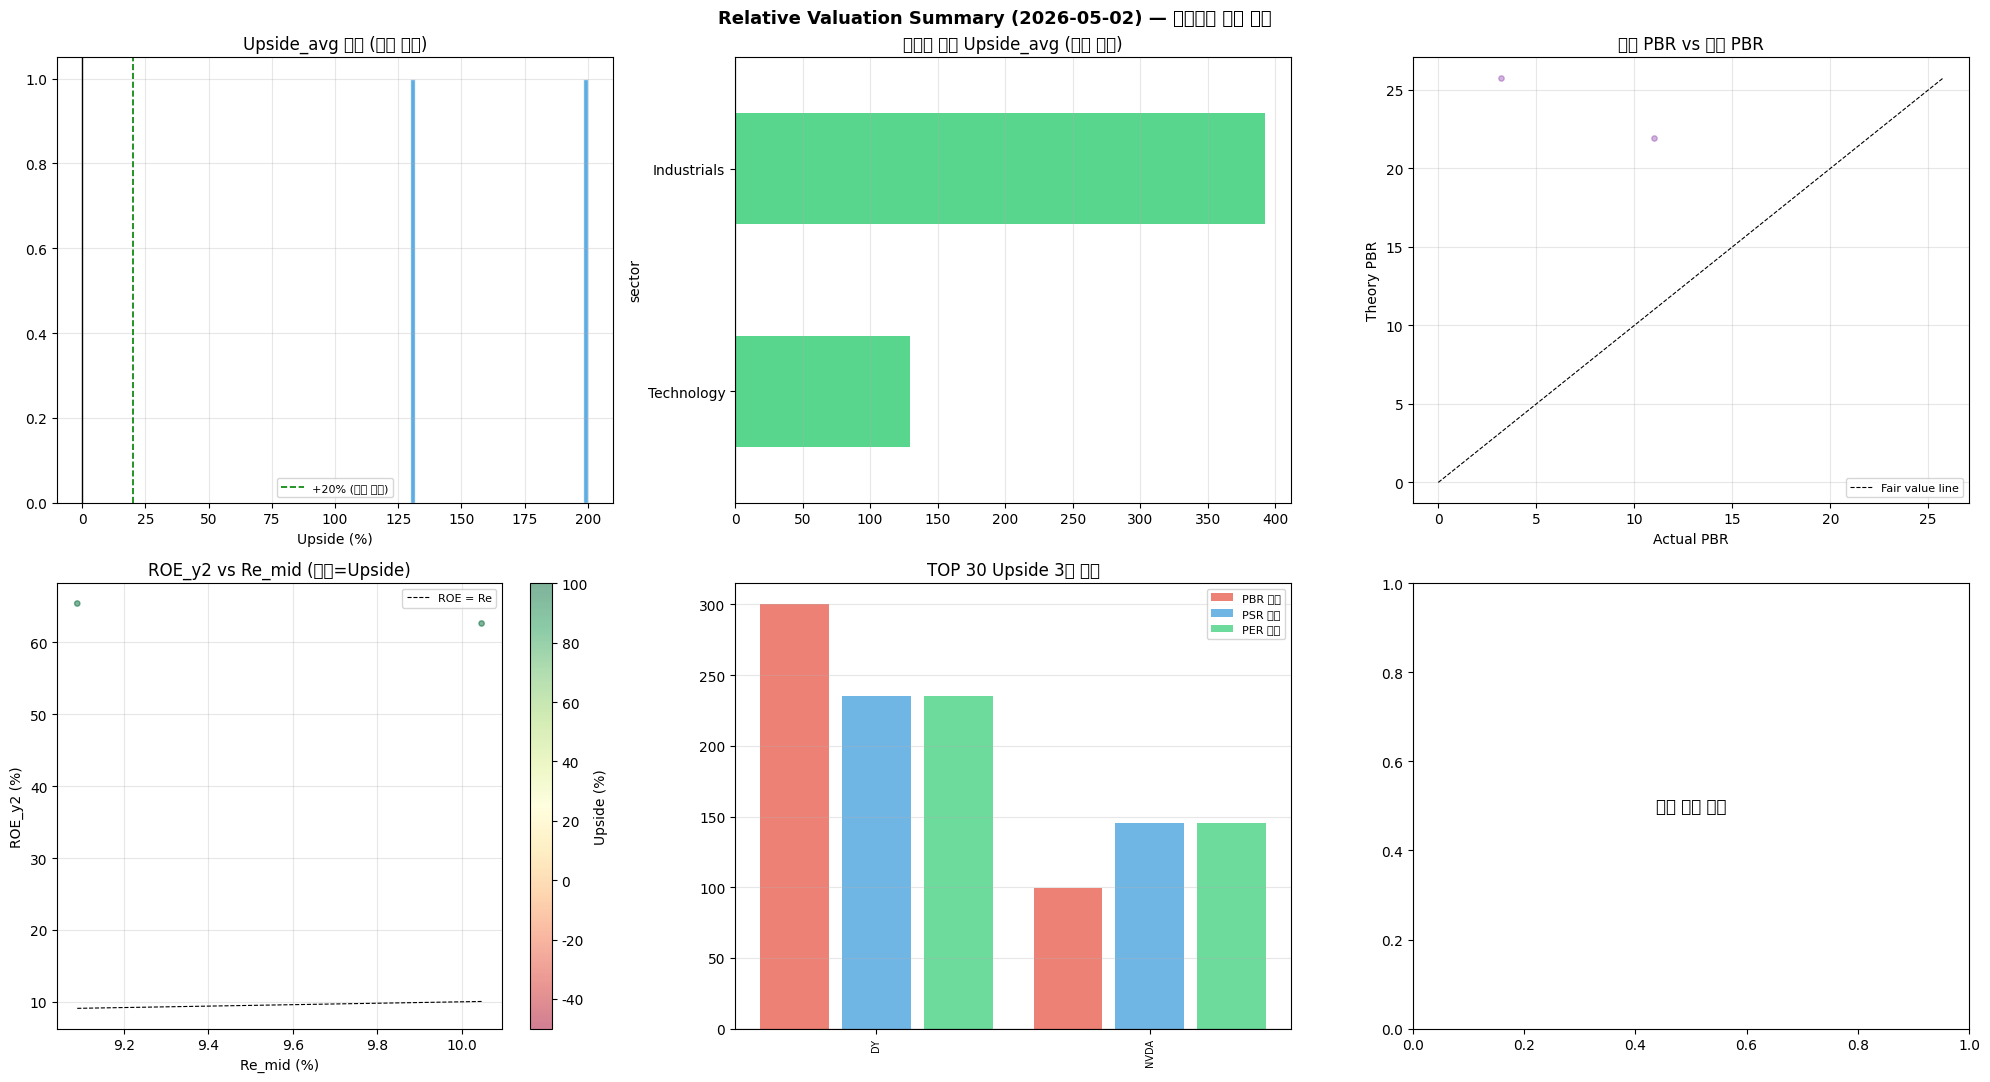

[AAPL] 데이터 없음
[MSFT] 데이터 없음


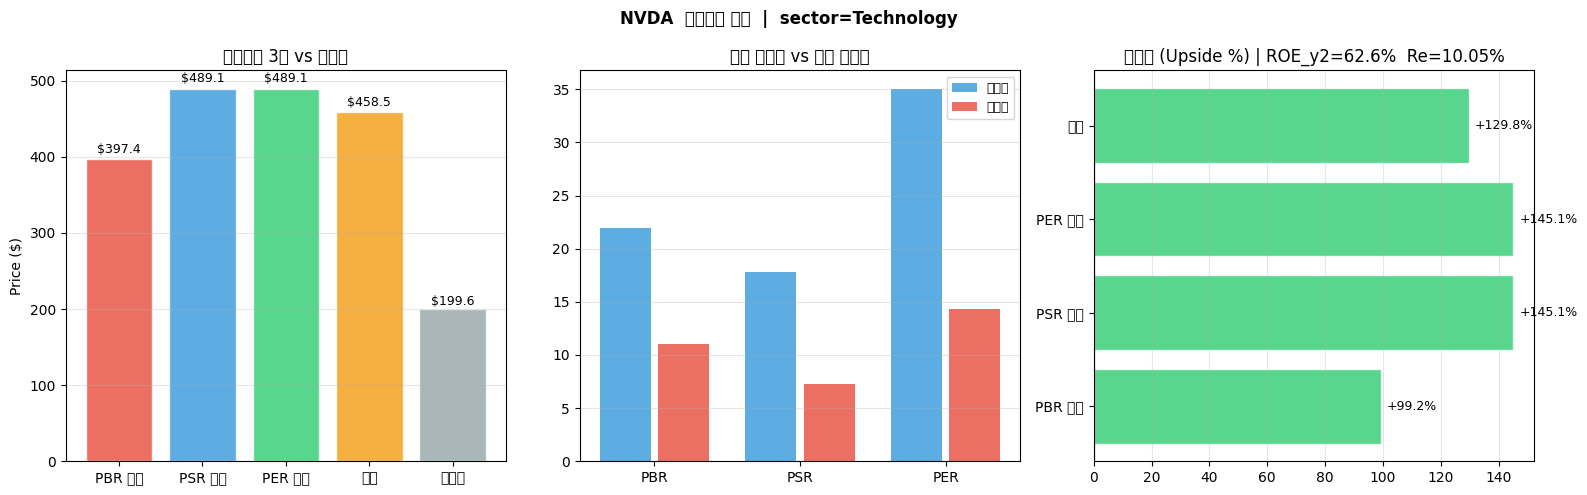

  [NVDA] sector=Technology  TP_avg=$458.54  Up_avg=129.8%  PBR_th=21.94x  g=7.53%


In [10]:
# ─────────────────────────────────────────────────────────────────
# DB에서 최신 결과 조회 + 시각화 (제외 업종 필터 포함)
# ─────────────────────────────────────────────────────────────────

conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(f"SELECT MAX(date) AS max_date FROM {TABLE_RESULT}")
        max_date = cur.fetchone()["max_date"]
        if max_date:
            cur.execute(f"""
                SELECT ticker, sector, is_excluded,
                       tp_pbr, tp_psr, tp_per, tp_avg,
                       upside_pbr, upside_psr, upside_per, upside_avg,
                       pbr_theory, psr_theory, per_theory,
                       actual_pbr, actual_psr, actual_per,
                       roe_y2, re_mid, g_est, beta_ensemble,
                       current_price
                FROM {TABLE_RESULT}
                WHERE date=%s AND tp_avg IS NOT NULL
                ORDER BY upside_avg DESC
            """, (max_date,))
            df_result = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

if max_date and not df_result.empty:
    df_incl = df_result[df_result["is_excluded"] == 0].copy()
    df_excl = df_result[df_result["is_excluded"] == 1].copy()

    print(f"[최신 실행일: {max_date}]  전체={len(df_result)}  포함={len(df_incl)}  제외={len(df_excl)}")

    # ── 통계 (포함 업종만) ──────────────────────────────────────
    print(f"\n[포함 업종 통계 — upside_avg]")
    print(df_incl["upside_avg"].describe().round(1).to_string())

    print(f"\n[포함 업종 TOP 30]")
    display(df_incl[["ticker","sector","tp_avg","upside_avg",
                      "pbr_theory","actual_pbr","roe_y2","re_mid"]].head(30))

    # ── 시각화 ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    fig.suptitle(f"Relative Valuation Summary ({max_date}) — 제외업종 필터 적용",
                 fontsize=13, fontweight="bold")

    # 1. Upside 분포 (포함 업종)
    ax = axes[0, 0]
    up_clean = df_incl["upside_avg"].dropna().clip(-100, 200)
    ax.hist(up_clean, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(0,  color="black", lw=1.0)
    ax.axvline(20, color="green", lw=1.2, ls="--", label="+20% (매수 후보)")
    ax.set_title("Upside_avg 분포 (포함 업종)"); ax.set_xlabel("Upside (%)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # 2. 업종별 평균 Upside
    ax = axes[0, 1]
    sect_up = df_incl.groupby("sector")["upside_avg"].median().sort_values()
    colors  = ["#e74c3c" if x < 0 else "#2ecc71" for x in sect_up]
    sect_up.plot(kind="barh", ax=ax, color=colors, alpha=0.8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title("업종별 중위 Upside_avg (포함 업종)"); ax.grid(axis="x", alpha=0.3)

    # 3. PBR theory vs actual
    ax = axes[0, 2]
    valid_pbr = df_incl[["pbr_theory","actual_pbr"]].dropna()
    valid_pbr = valid_pbr[(valid_pbr["pbr_theory"]<50) & (valid_pbr["actual_pbr"]<50)]
    ax.scatter(valid_pbr["actual_pbr"], valid_pbr["pbr_theory"],
               alpha=0.4, s=15, color="#8e44ad")
    lim = max(valid_pbr.max().max(), 1)
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="Fair value line")
    ax.set_xlabel("Actual PBR"); ax.set_ylabel("Theory PBR")
    ax.set_title("이론 PBR vs 실제 PBR"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # 4. ROE_y2 vs Re_mid 산점도
    ax = axes[1, 0]
    valid_re = df_incl[["roe_y2","re_mid","upside_avg"]].dropna()
    valid_re = valid_re[(valid_re["roe_y2"].abs()<2)]
    sc = ax.scatter(valid_re["re_mid"]*100, valid_re["roe_y2"]*100,
                    c=valid_re["upside_avg"].clip(-100,200),
                    cmap="RdYlGn", alpha=0.5, s=15, vmin=-50, vmax=100)
    plt.colorbar(sc, ax=ax, label="Upside (%)")
    lim_x = np.linspace(valid_re["re_mid"].min(), valid_re["re_mid"].max(), 50)*100
    ax.plot(lim_x, lim_x, "k--", lw=0.8, label="ROE = Re")
    ax.set_xlabel("Re_mid (%)"); ax.set_ylabel("ROE_y2 (%)")
    ax.set_title("ROE_y2 vs Re_mid (색상=Upside)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # 5. TP 3종 비교 (포함 업종 상위 30)
    ax = axes[1, 1]
    top30 = df_incl.head(30).set_index("ticker")
    x = range(len(top30))
    ax.bar([i-0.3 for i in x], top30["upside_pbr"].clip(-100,300), 0.25,
           label="PBR 기반", alpha=0.7, color="#e74c3c")
    ax.bar([i     for i in x], top30["upside_psr"].clip(-100,300), 0.25,
           label="PSR 기반", alpha=0.7, color="#3498db")
    ax.bar([i+0.3 for i in x], top30["upside_per"].clip(-100,300), 0.25,
           label="PER 기반", alpha=0.7, color="#2ecc71")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(list(x)); ax.set_xticklabels(top30.index, rotation=90, fontsize=7)
    ax.set_title("TOP 30 Upside 3종 비교"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

    # 6. 제외 업종 분포
    ax = axes[1, 2]
    if not df_excl.empty:
        excl_cnt_by_sect = df_excl["sector"].value_counts()
        excl_cnt_by_sect.plot(kind="bar", ax=ax, color="#e67e22", alpha=0.8, edgecolor="white")
        ax.set_title(f"제외 업종 분포 ({len(df_excl)}개 제외)")
        ax.set_xlabel("업종"); ax.set_ylabel("종목 수"); ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)
    else:
        ax.text(0.5, 0.5, "제외 종목 없음", transform=ax.transAxes,
                ha="center", va="center", fontsize=12)

    plt.tight_layout()
    plt.show()

    # ── 개별 종목 시각화 ─────────────────────────────────────────
    VIZ_TICKERS = ["AAPL","MSFT","NVDA"]  # 변경 가능

    for tk in VIZ_TICKERS:
        row = df_result[df_result["ticker"]==tk]
        if row.empty: print(f"[{tk}] 데이터 없음"); continue
        r = row.iloc[0]

        fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
        fig2.suptitle(f"{tk}  상대가치 평가  |  sector={r['sector']}  "
                      f"{'[제외 업종]' if r['is_excluded'] else ''}",
                      fontsize=12, fontweight="bold")

        # TP 3종 vs 현재가
        ax = axes2[0]
        cats    = ["PBR 기반","PSR 기반","PER 기반","평균","현재가"]
        vals    = [r["tp_pbr"],r["tp_psr"],r["tp_per"],r["tp_avg"],r["current_price"]]
        colors2 = ["#e74c3c","#3498db","#2ecc71","#f39c12","#95a5a6"]
        bars = ax.bar(cats, vals, color=colors2, alpha=0.8, edgecolor="white")
        for bar, val in zip(bars, vals):
            if not (isinstance(val, float) and np.isnan(val)):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                        f"${val:.1f}", ha="center", va="bottom", fontsize=9)
        ax.set_title("적정주가 3종 vs 현재가"); ax.set_ylabel("Price ($)"); ax.grid(axis="y", alpha=0.3)

        # 이론 vs 실제 멀티플
        ax = axes2[1]
        mult_cats = ["PBR","PSR","PER"]
        theory_v  = [r["pbr_theory"],r["psr_theory"],r["per_theory"]]
        actual_v  = [r["actual_pbr"],r["actual_psr"],r["actual_per"]]
        x2 = range(3)
        ax.bar([i-0.2 for i in x2], theory_v, 0.35, label="이론값", color="#3498db", alpha=0.8)
        ax.bar([i+0.2 for i in x2], actual_v, 0.35, label="실제값", color="#e74c3c", alpha=0.8)
        ax.set_xticks(list(x2)); ax.set_xticklabels(mult_cats)
        ax.set_title("이론 멀티플 vs 실제 멀티플"); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

        # Upside 수평 바
        ax = axes2[2]
        up_cats = ["PBR 기반","PSR 기반","PER 기반","평균"]
        up_vals = [r["upside_pbr"],r["upside_psr"],r["upside_per"],r["upside_avg"]]
        up_clean2 = [v if (v is not None and not (isinstance(v,float) and np.isnan(v))) else 0 for v in up_vals]
        colors3 = ["#2ecc71" if v>=0 else "#e74c3c" for v in up_clean2]
        bars2 = ax.barh(up_cats, up_clean2, color=colors3, alpha=0.8, edgecolor="white")
        ax.axvline(0, color="black", lw=0.8)
        for bar, val in zip(bars2, up_clean2):
            ax.text(val + (2 if val>=0 else -2), bar.get_y()+bar.get_height()/2,
                    f"{val:+.1f}%", va="center", fontsize=9,
                    ha="left" if val>=0 else "right")
        ax.set_title(f"괴리율 (Upside %) | ROE_y2={r['roe_y2']:.1%}  Re={r['re_mid']:.2%}")
        ax.grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.show()
        print(f"  [{tk}] sector={r['sector']}  TP_avg=${r['tp_avg']:.2f}  "
              f"Up_avg={r['upside_avg']:.1f}%  PBR_th={r['pbr_theory']:.2f}x  "
              f"g={r['g_est']:.2%}")


## Cell 7 · 민감도 분석 — g × Re 격자 (PBR / PSR / PER 적정주가)

**분석 목적**: 영구성장률 g 와 요구수익률 Re 가 동시에 변할 때  
PBR·PSR·PER 이론 멀티플과 적정주가가 어떻게 달라지는지 히트맵으로 확인.

| 파라미터 | 범위 |
|---|---|
| g (영구성장률) | 0% ~ 7% (0.5%p 간격, 해자 구간 표시) |
| Re (요구수익률) | Re_low ~ Re_high ± 확장 (0.5%p 간격) |

**해자 구간 기준 (v7 = v6 유지)**  
- 저성장(ROE < 15%): g_cap = GDP(4%)  
- 중성장(ROE < 30%): g_cap = min(8%, Re×0.75)  
- 고성장(ROE ≥ 30%): g_cap = min(8%, Re×0.75)

**v7 추가**: β source 는 메인 cell 결과 (Beta_Cost_of_Equity 시트) 참조  
- `fdr_ols`: FDR OLS 회귀 정상  
- `fmp_*`: FMP API fallback  
- `sector_default`: ⚠ 섹터 평균 (매수 후보 풀 검토 필요)
